In [209]:
data_dir = '/home/mjehangir/telomere-sv-analysis/data/'

In [210]:
setwd(data_dir)

In [211]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(tibble)
library(ggridges)



In [212]:
# Read the CSV file into a data frame
df <- read.csv("gliomas_telomers.csv", header = TRUE)

# Set column names
#colnames(df) <- c("Sample", "Chromosome", "Value", "Other_1", "Arm")

# View the data
head(df)


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


In [213]:
df$final_average_TL_p75_kb <- df$final_average_TL_p75 / 1000
head(df)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>
1,2436A,chr1p,5221.000,1,p,5.221000
2,2436A,chr1q,5051.167,1,q,5.051167
3,3188,chr1p,1642.500,1,p,1.642500
4,3188,chr1q,3086.500,1,q,3.086500
5,3988,chr1p,2347.500,1,p,2.347500
6,3988,chr1q,5083.000,1,q,5.083000


Picking joint bandwidth of 632



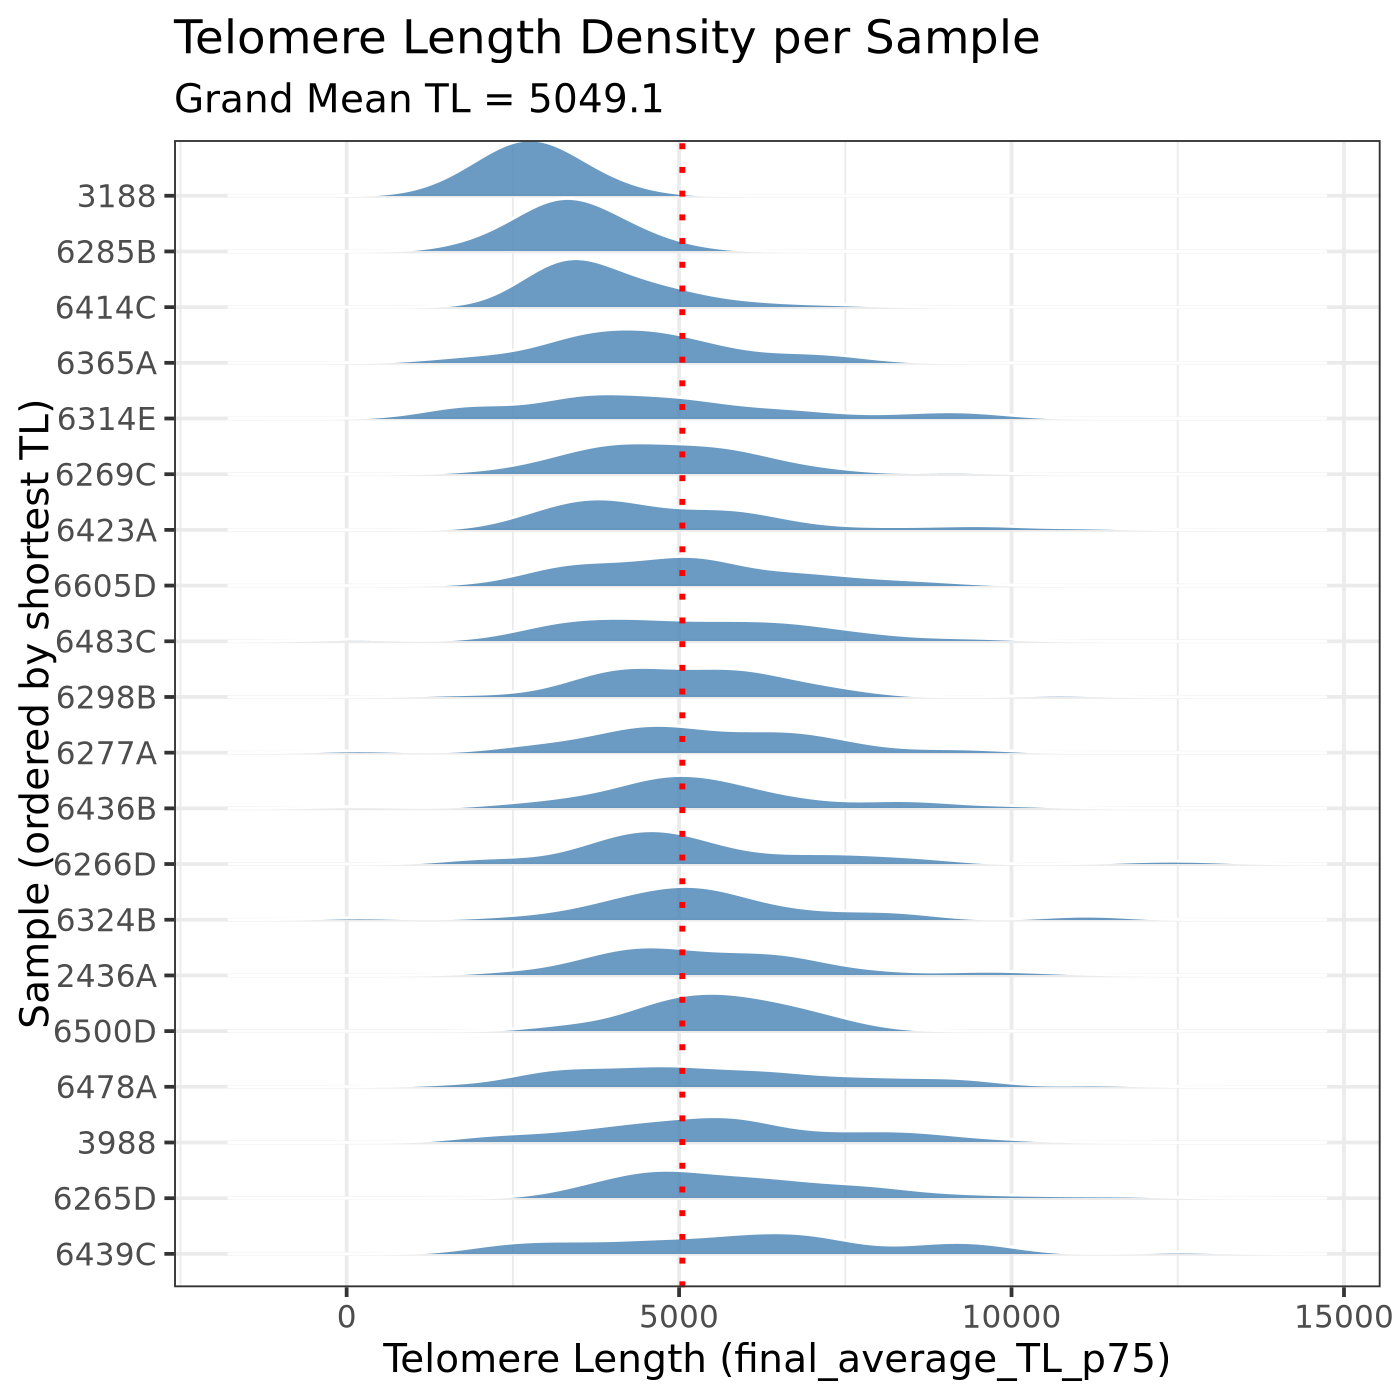

In [214]:
# Calculate mean TL per sample and reorder samples
sample_avg <- df %>%
  group_by(Sample_prefix) %>%
  summarise(mean_TL = mean(final_average_TL_p75, na.rm = TRUE)) %>%
  arrange(mean_TL)

df$Sample_prefix <- factor(df$Sample_prefix, levels = sample_avg$Sample_prefix)

# Calculate grand mean telomere length across all samples
grand_mean <- mean(df$final_average_TL_p75, na.rm = TRUE)

options(repr.plot.width = 7, repr.plot.height = 7, repr.plot.res = 200)

# Plot with grand mean vertical dotted line
ggplot(df, aes(x = final_average_TL_p75, y = Sample_prefix)) +
  geom_density_ridges(scale = 1, alpha = 0.8, fill = "#4682B4", color = "white") +
  geom_vline(xintercept = grand_mean, linetype = "dotted", color = "red", size = 1) +
  scale_y_discrete(limits = rev(levels(df$Sample_prefix))) +
  labs(
    title = "Telomere Length Density per Sample",
    subtitle = paste("Grand Mean TL =", round(grand_mean, 1)),
    x = "Telomere Length (final_average_TL_p75)",
    y = "Sample (ordered by shortest TL)"
  ) +
  theme_bw(base_size = 14)


Picking joint bandwidth of 812



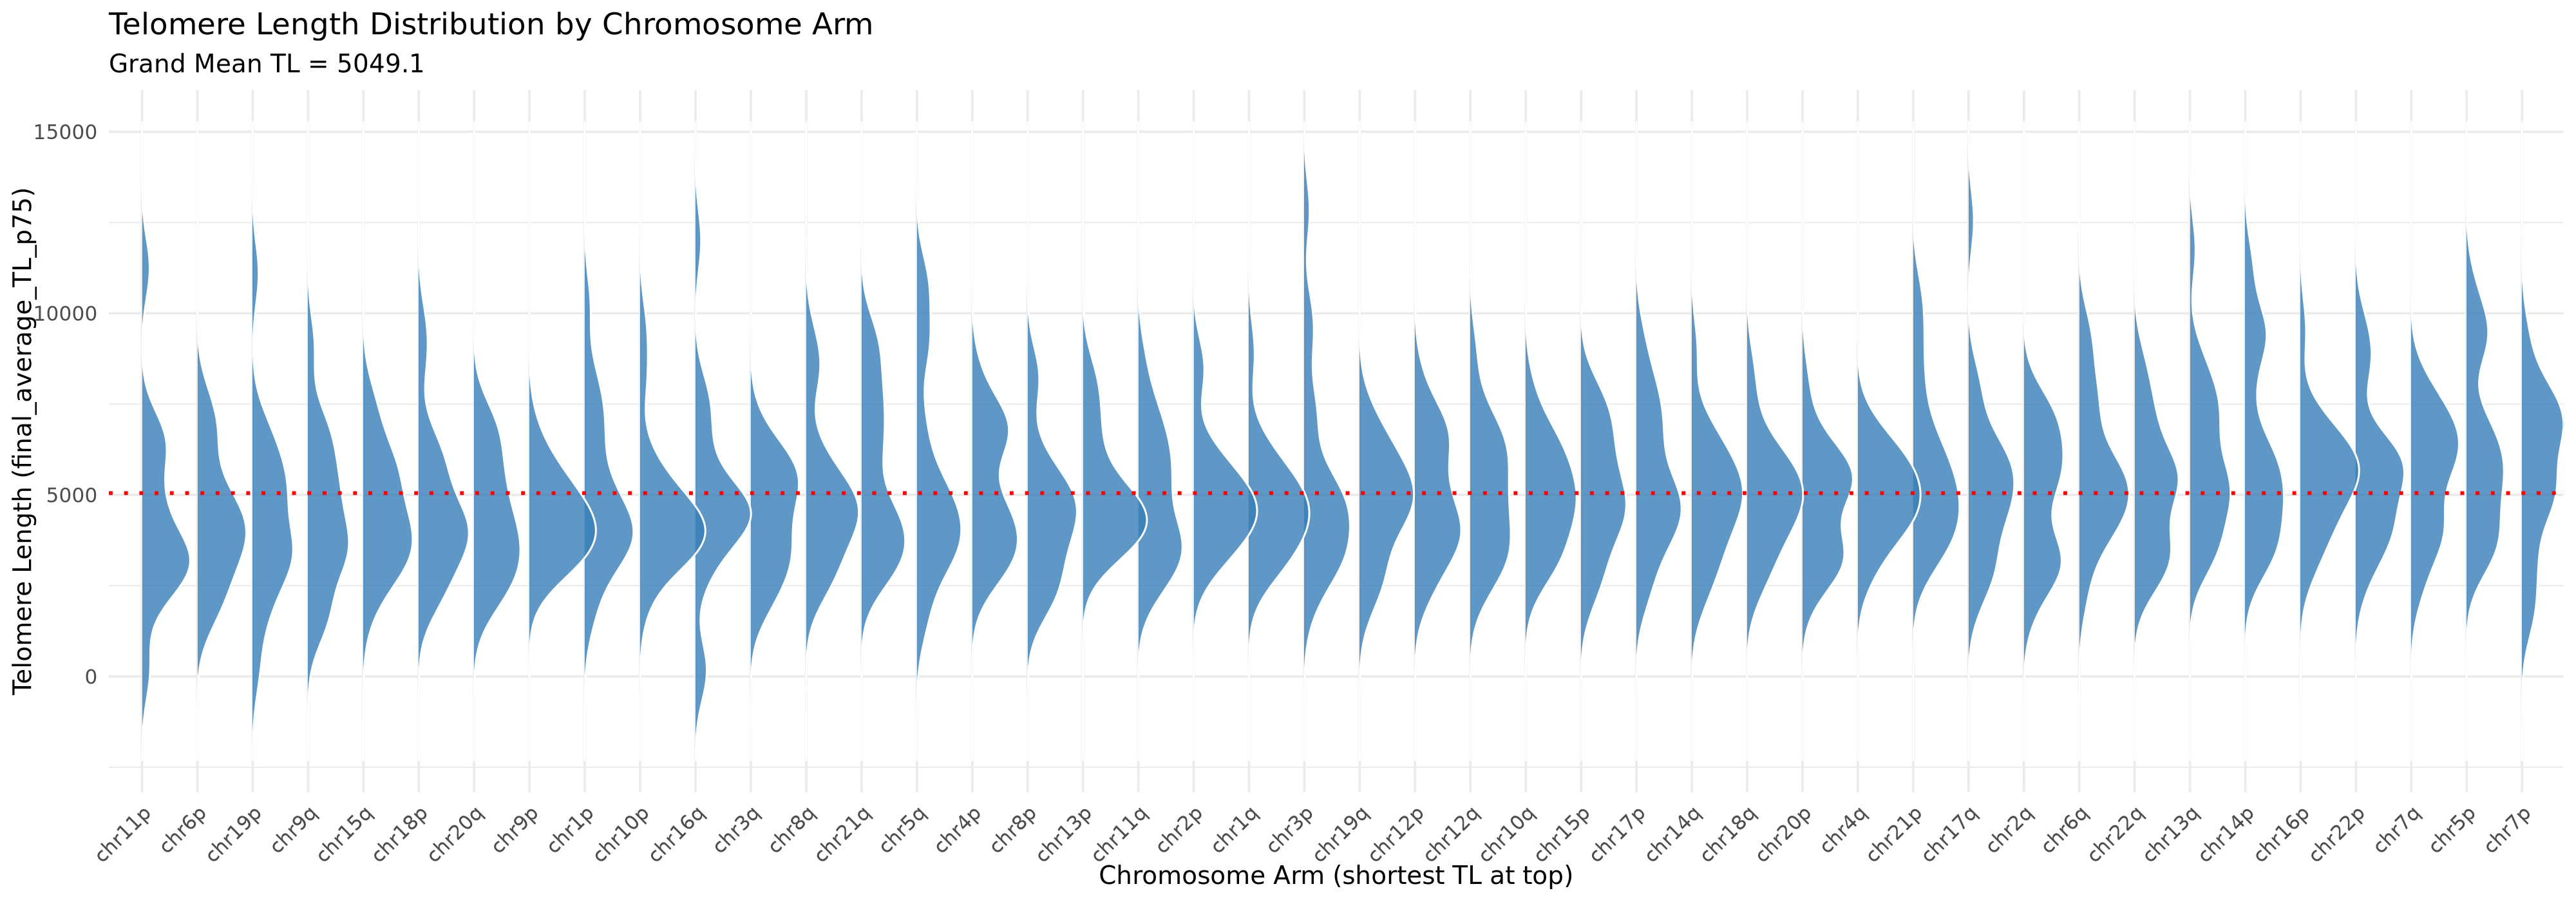

In [198]:
# Step 1: Order chr by median TL
arm_order <- df %>%
  group_by(chr) %>%
  summarise(median_TL = median(final_average_TL_p75, na.rm = TRUE)) %>%
  arrange(median_TL) %>%
  pull(chr)

df$chr <- factor(df$chr, levels = arm_order)

# Step 2: Calculate grand mean
grand_mean <- mean(df$final_average_TL_p75, na.rm = TRUE)

options(repr.plot.width = 20, repr.plot.height = 7, repr.plot.res = 200)

ggplot(df, aes(x = final_average_TL_p75, y = chr)) +
  geom_density_ridges(
    scale = 1.2,
    alpha = 0.8,
    fill = "#377eb8",
    color = "white"
  ) +
  geom_vline(xintercept = grand_mean, linetype = "dotted", color = "red", size = 1) +
  labs(
    title = "Telomere Length Distribution by Chromosome Arm",
    subtitle = paste("Grand Mean TL =", round(grand_mean, 1)),
    x = "Telomere Length (final_average_TL_p75)",
    y = "Chromosome Arm (shortest TL at top)"
  ) +
  coord_flip() +
  theme_minimal(base_size = 14)+
theme(axis.text.x = element_text(angle = 45, hjust = 1))




In [142]:
library(tidyr)

# Assuming your data frame is named 'df'
df_wide <- df %>% 
  pivot_wider(
    id_cols = Sample_prefix,
    names_from = chr,
    values_from = final_average_TL_p75_kb
  )

In [143]:
# Convert to matrix, excluding the Sample_prefix column
mat <- as.matrix(df_wide[, -1])

# Set row names to Sample_prefix
rownames(mat) <- df_wide$Sample_prefix

In [144]:
# Get unique chr, chr_order, and arm combinations
chr_order_df <- df %>% 
  select(chr, chr_order, arm) %>% 
  distinct() %>% 
  arrange(chr_order, arm)

# Extract the ordered chromosome arms
ordered_chr <- chr_order_df$chr

# Reorder the matrix columns
mat_ordered <- mat[, ordered_chr, drop = FALSE]

In [145]:


# Assume 'df' is your data frame with Sample_prefix, chr, final_average_TL_p75, etc.
# Reshape data into wide format
df_wide <- df %>%
  pivot_wider(
    id_cols = chr,                # Rows are chromosome arms
    names_from = Sample_prefix,   # Columns are samples
    values_from = final_average_TL_p75_kb  # Values are TL p75
  )

# Convert to a matrix, excluding the 'chr' column
mat <- as.matrix(df_wide[, -1])
rownames(mat) <- df_wide$chr

# Optional: Add row annotation to show chromosome numbers
chr_order_df <- df %>%
  select(chr, chr_order, arm) %>%
  distinct() %>%
  arrange(chr_order, arm)
annot_row <- data.frame(
  Chromosome = factor(chr_order_df$chr_order),
  row.names = chr_order_df$chr
)



In [146]:
head(mat)

,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1p,5.221000,1.64250,2.347500,6.548000,4.22400,4.019000,5.31100,3.17100,4.19800,3.9030,8.373,4.965000,3.577667,3.424500,10.227000,3.435750,7.364250,7.5700,4.35200,6.38900
chr1q,5.051167,3.08650,5.083000,3.906333,4.33850,4.756800,4.70475,3.89800,6.41925,NA,4.714,4.419250,2.859000,6.019500,3.299333,3.943500,8.899333,5.5430,5.63000,3.09975
chr2p,4.118250,3.43925,3.395000,4.845375,4.47250,6.108250,4.54425,3.23150,4.91950,5.5380,8.341,3.297750,4.373500,8.609000,5.830500,5.902500,5.008500,4.2480,4.89475,4.37400
chr2q,6.963000,1.92800,NA,5.738000,4.36475,3.223000,5.42350,3.29800,NA,3.1710,6.927,7.584500,6.082000,5.884000,NA,5.111500,2.859000,3.1410,7.22400,NA
chr3p,4.739200,2.89050,10.037500,5.329500,12.82950,9.171000,5.09790,2.98500,5.97850,1.9220,3.953,3.834333,7.371250,3.541000,4.486500,4.767667,7.234000,3.0600,4.69800,3.37975
chr3q,4.078050,2.36080,2.135214,4.617500,5.56200,4.462125,6.06900,2.05025,6.84450,3.4155,5.117,3.536600,3.291500,3.244875,5.081417,6.033267,5.576500,5.8345,5.41150,3.09625


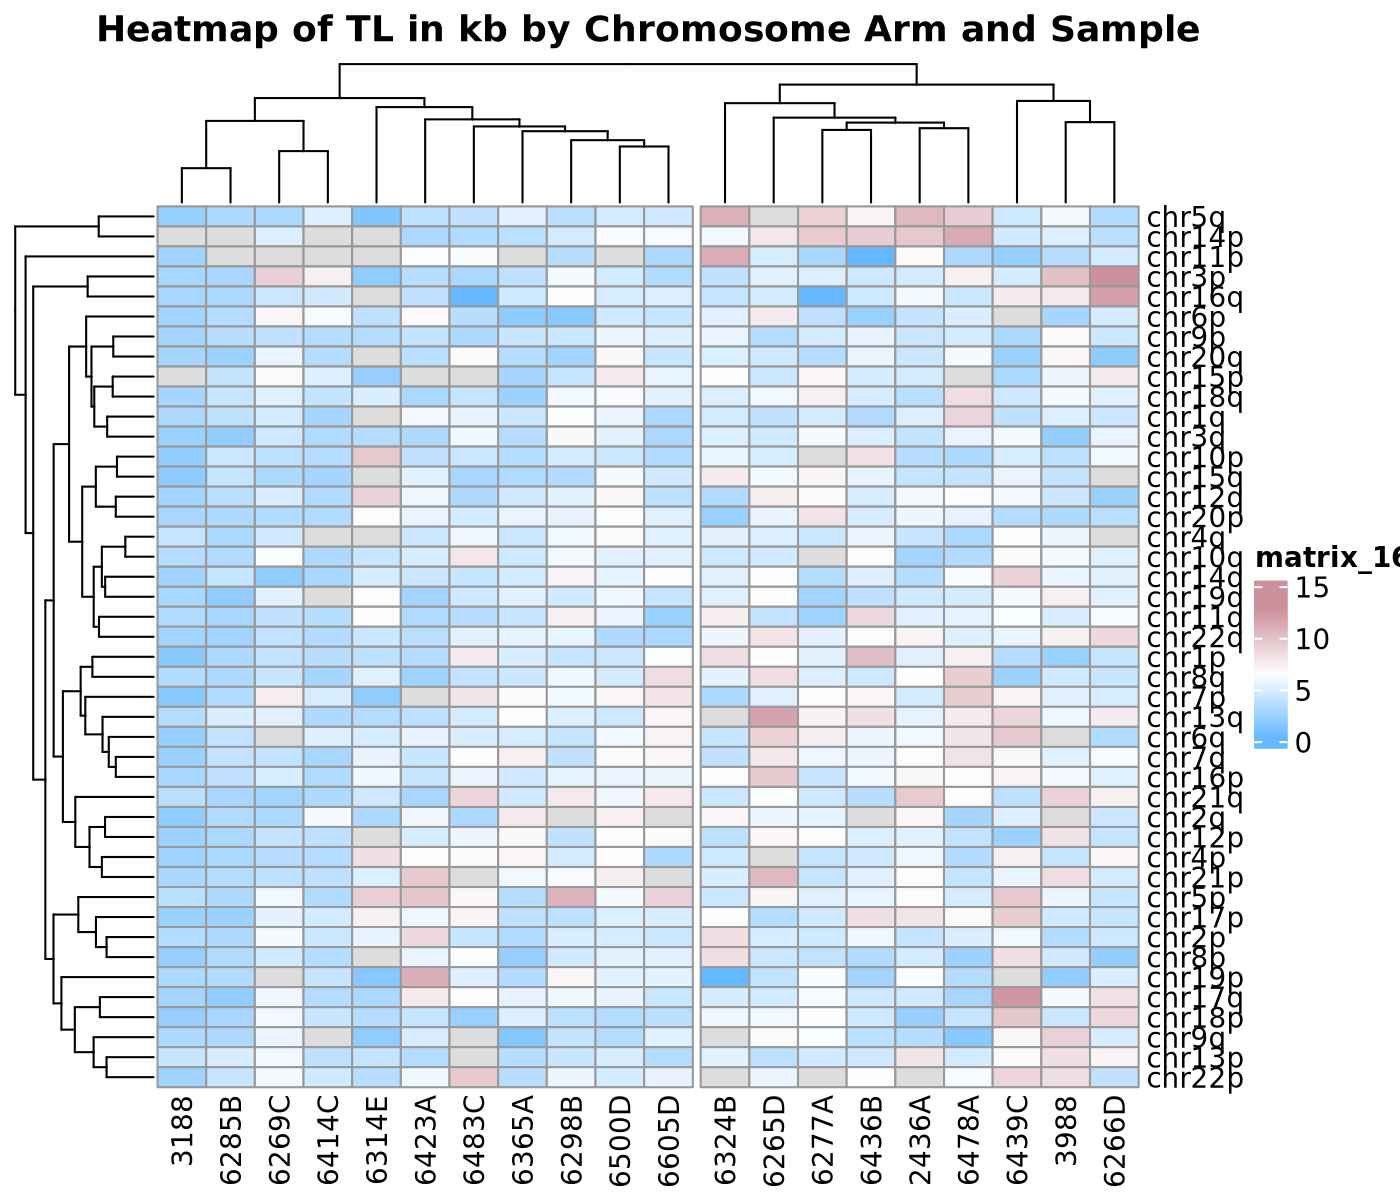

In [147]:
# Create heatmap with chromosome clustering
options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 200)

pheatmap(
  mat,                                # Matrix with chromosomes as rows, samples as columns
  cluster_rows = TRUE,                # Cluster chromosomes
  cluster_cols = TRUE,
    column_split = 2,
      color = colorRampPalette(c("steelblue1", "white", "pink3"))(50),
  main = "Heatmap of TL in kb by Chromosome Arm and Sample"
)


In [148]:
head(df)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>
1,2436A,chr1p,5221.000,1,p,5.221000
2,2436A,chr1q,5051.167,1,q,5.051167
3,3188,chr1p,1642.500,1,p,1.642500
4,3188,chr1q,3086.500,1,q,3.086500
5,3988,chr1p,2347.500,1,p,2.347500
6,3988,chr1q,5083.000,1,q,5.083000


In [149]:
sv_summary <- read.delim2("sv_summary_rate_prop_pq.tsv", header = TRUE)
head(sv_summary)

,type,chr,filename,arm,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,region
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,DEL,chr1,2436A,p,581,201164,248.956422,2.3337417662598,0.000808028965004968,chr1p
2,DEL,chr1,2436A,q,551,173200,248.956422,2.2132387490691,0.000695704085914281,chr1q
3,DEL,chr1,3188,p,330,389636135,248.956422,1.32553318909765,1.56507766246737,chr1p
4,DEL,chr1,3188,q,378,82339694,248.956422,1.51833801660276,0.330739385385286,chr1q
5,DEL,chr1,3988,p,523,256730,248.956422,2.10076926635779,0.00103122465344557,chr1p
6,DEL,chr1,3988,q,459,194912,248.956422,1.84369616301764,0.000782916136222427,chr1q


In [150]:
# Load libraries
library(dplyr)
library(ggplot2)
library(ggpubr)

# --- Step 1: Define short TL group
short_tl_samples <- c("3188", "6285B", "6269C", "6414C")

# --- Step 2: Add TL group label
telomere_data <- df %>%
  mutate(TL_group = ifelse(Sample_prefix %in% short_tl_samples, "Short TL", "Other"))

In [151]:
head(telomere_data)

,Sample_prefix,chr,final_average_TL_p75,chr_order,arm,final_average_TL_p75_kb,TL_group
,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
1,2436A,chr1p,5221.000,1,p,5.221000,Other
2,2436A,chr1q,5051.167,1,q,5.051167,Other
3,3188,chr1p,1642.500,1,p,1.642500,Short TL
4,3188,chr1q,3086.500,1,q,3.086500,Short TL
5,3988,chr1p,2347.500,1,p,2.347500,Other
6,3988,chr1q,5083.000,1,q,5.083000,Other


In [152]:
# Step 2: Perform the full merge between `sv_summary` and `telomere_data`
merged_data <- sv_summary %>%
  filter(type %in% c("DEL", "DUP", "INS", "INV")) %>%  # Filtering for relevant SV types
  left_join(telomere_data, by = c("filename" = "Sample_prefix", "region" = "chr")) %>%
  filter(!is.na(final_average_TL_p75))  # Ensuring no missing TL data
head(merged_data)

,type,chr,filename,arm.x,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,region,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,TL_group
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
1,DEL,chr1,2436A,p,581,201164,248.956422,2.3337417662598,0.000808028965004968,chr1p,5221.000,1,p,5.221000,Other
2,DEL,chr1,2436A,q,551,173200,248.956422,2.2132387490691,0.000695704085914281,chr1q,5051.167,1,q,5.051167,Other
3,DEL,chr1,3188,p,330,389636135,248.956422,1.32553318909765,1.56507766246737,chr1p,1642.500,1,p,1.642500,Short TL
4,DEL,chr1,3188,q,378,82339694,248.956422,1.51833801660276,0.330739385385286,chr1q,3086.500,1,q,3.086500,Short TL
5,DEL,chr1,3988,p,523,256730,248.956422,2.10076926635779,0.00103122465344557,chr1p,2347.500,1,p,2.347500,Other
6,DEL,chr1,3988,q,459,194912,248.956422,1.84369616301764,0.000782916136222427,chr1q,5083.000,1,q,5.083000,Other


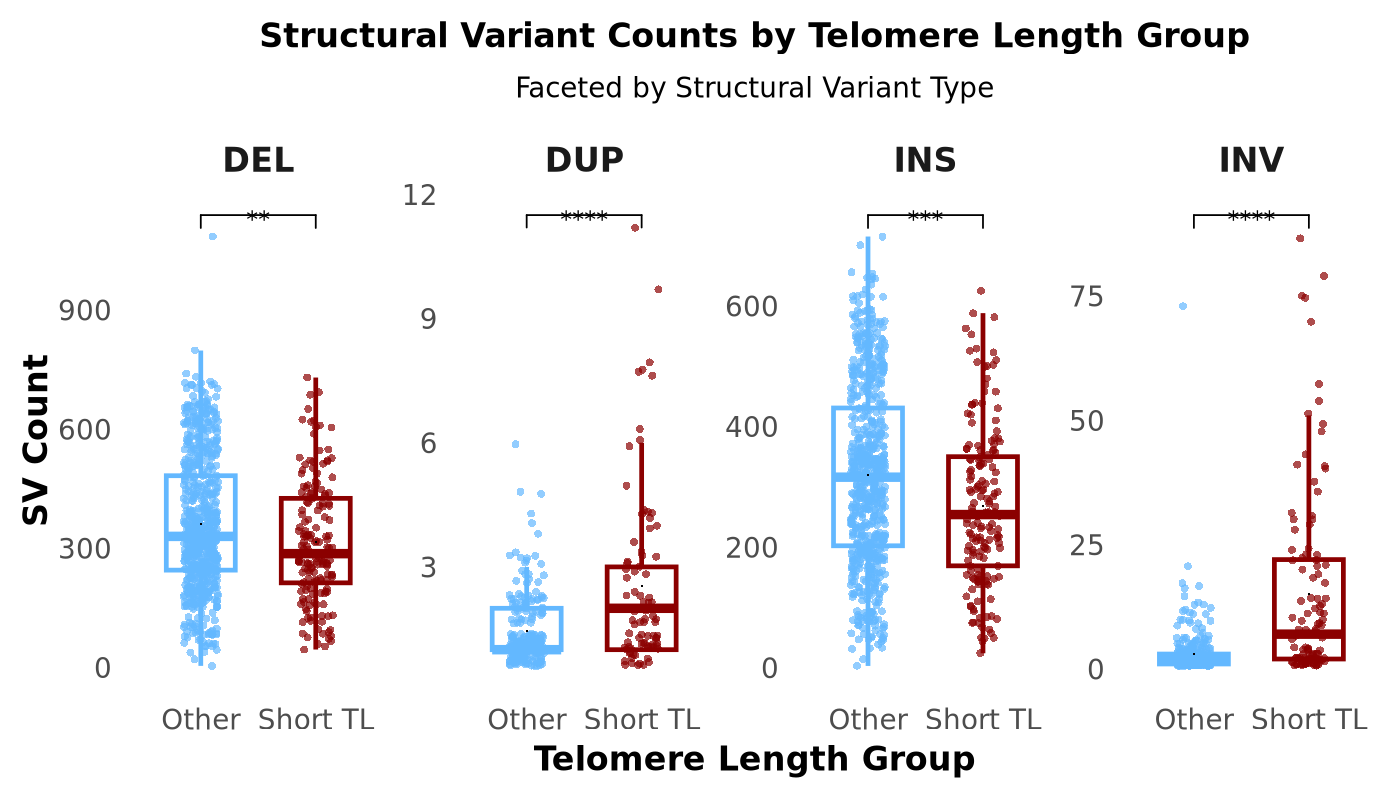

In [153]:
# Step 3: Publication-quality plot
options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)


p <- ggplot(merged_data, aes(x = TL_group, y = sv_count, color = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.4, width = 0.6, size = 0.8) +  # Clean boxplot with thicker lines
  geom_jitter(width = 0.15, size = 1, alpha = 0.7, shape = 16) +  # Jittered dots with controlled overlap
  stat_summary(fun = mean, geom = "point", shape = 15, size = 0, color = "black", fill = "black") +  # Mean point
  facet_wrap(~ type, nrow = 1, scales = "free_y") +  # Faceting by SV type
  stat_compare_means(method = "wilcox.test", label = "p.signif", 
                     comparisons = list(c("Short TL", "Other")),
                     label.y.npc = "top", size = 3, vjust = 1) +  # Significance labels
  scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +  # Updated color palette
  labs(
    title = "Structural Variant Counts by Telomere Length Group",
    x = "Telomere Length Group",
    y = "SV Count",
    subtitle = "Faceted by Structural Variant Type"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid.major = element_blank(),  # Remove major grid lines
    panel.grid.minor = element_blank(),  # Remove minor grid lines
    axis.title = element_text(face = "bold", size = 12),  # Bold axis labels
    axis.text = element_text(size = 10),  # Axis tick labels size
    strip.text = element_text(face = "bold", size = 12),  # Bold facet labels
    plot.title = element_text(face = "bold", size = 12, hjust = 0.5),  # Centered plot title
    plot.subtitle = element_text(size = 10, hjust = 0.5),  # Subtitle size and alignment
    legend.position = "none"  # Remove legend for cleaner look
  )

# Step 4: Show the plot
print(p)
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data//plots_f2/SV_counts_by_TL_group.pdf", plot = p,
     #  width = 7, height = 4, units = "in", dpi = 300, useDingbats = FALSE)


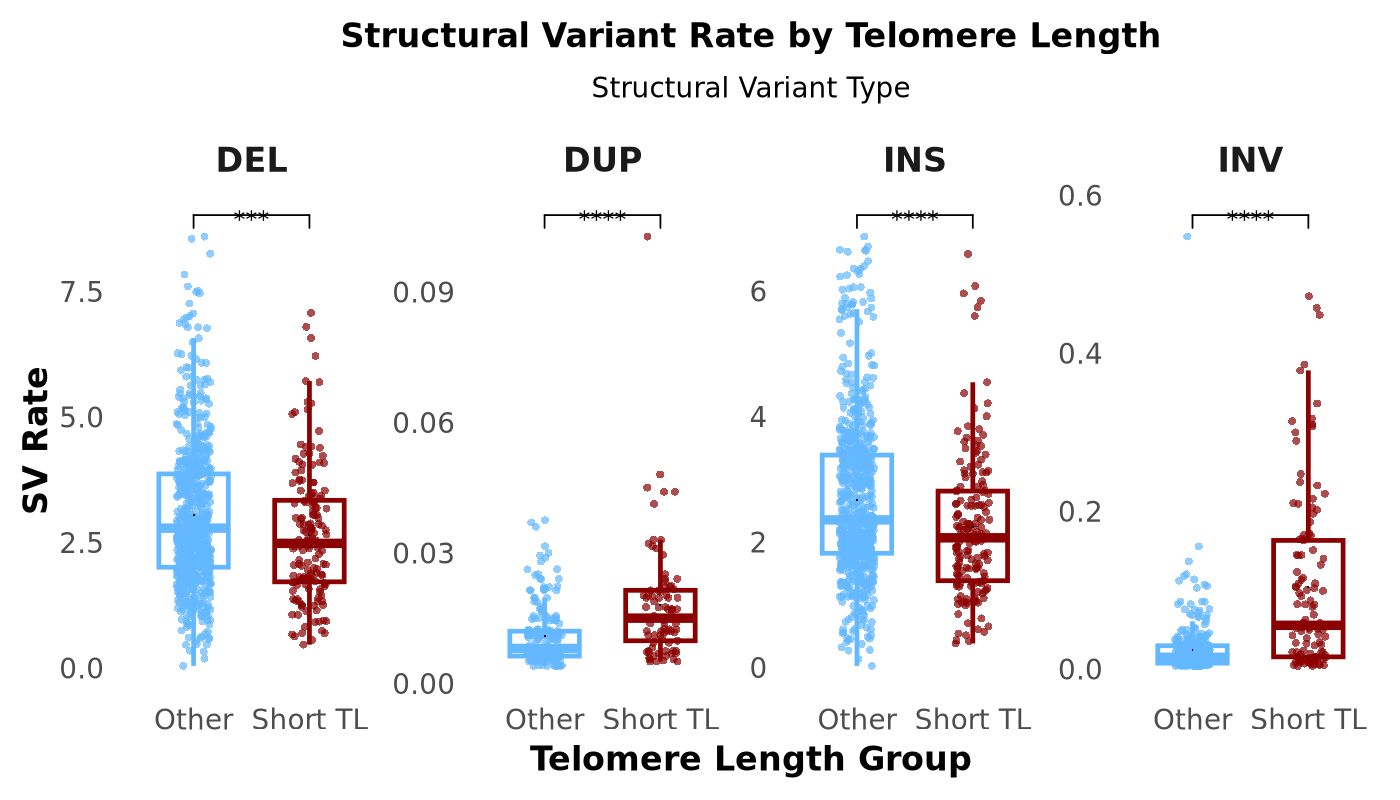

In [154]:
library(ggplot2)
library(ggpubr)
library(dplyr)

# Step 1: Ensure sv_rate is numeric and remove rows with NA
merged_data <- merged_data %>%
  mutate(sv_rate = as.numeric(sv_rate)) %>%
  filter(!is.na(sv_rate))

# Step 2–4: Create the plot
options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)

t <- ggplot(merged_data, aes(x = TL_group, y = sv_rate, color = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.4, width = 0.6, size = 0.8) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.7, shape = 16) +
  stat_summary(fun = mean, geom = "point", shape = 15, size = 0, color = "black", fill = "black") +
  facet_wrap(~ type, nrow = 1, scales = "free_y") +
  stat_compare_means(
    method = "wilcox.test",
    aes(group = TL_group),
    label = "p.signif",
    comparisons = list(c("Short TL", "Other")),
    label.y.npc = "top",
    size = 3,
    vjust = 1
  ) +
  scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
  labs(
    title = "Structural Variant Rate by Telomere Length",
    x = "Telomere Length Group",
    y = "SV Rate",
    subtitle = "Structural Variant Type"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10),
    strip.text = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold", size = 12, hjust = 0.5),
    plot.subtitle = element_text(size = 10, hjust = 0.5),
    legend.position = "none"
  )

print(t)
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data//plots_f2/SV_rate_by_TL_group.pdf", plot = t,
    #   width = 7, height = 4, units = "in", dpi = 300, useDingbats = FALSE)


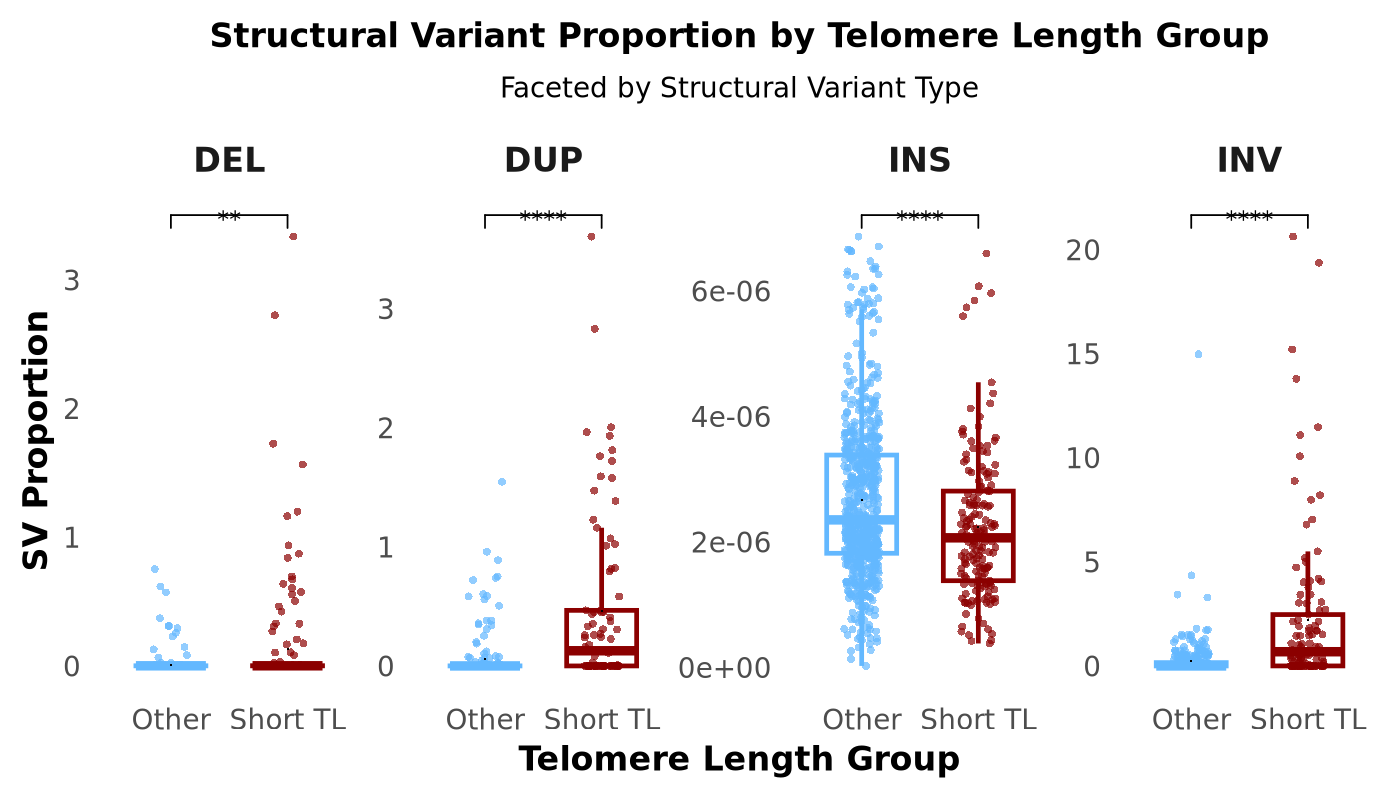

In [155]:
library(ggplot2)
library(ggpubr)
library(dplyr)

# Step 1: Ensure sv_rate is numeric and remove rows with NA
merged_data <- merged_data %>%
  mutate(sv_proportion = as.numeric(sv_proportion)) %>%
  filter(!is.na(sv_proportion))

# Step 2–4: Create the plot
options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)

r <- ggplot(merged_data, aes(x = TL_group, y = sv_proportion, color = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.4, width = 0.6, size = 0.8) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.7, shape = 16) +
  stat_summary(fun = mean, geom = "point", shape = 15, size = 0, color = "black", fill = "black") +
  facet_wrap(~ type, nrow = 1, scales = "free_y") +
  stat_compare_means(
    method = "wilcox.test",
    aes(group = TL_group),
    label = "p.signif",
    comparisons = list(c("Short TL", "Other")),
    label.y.npc = "top",
    size = 3,
    vjust = 1
  ) +
  scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
  labs(
    title = "Structural Variant Proportion by Telomere Length Group",
    x = "Telomere Length Group",
    y = "SV Proportion",
    subtitle = "Faceted by Structural Variant Type"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10),
    strip.text = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold", size = 12, hjust = 0.5),
    plot.subtitle = element_text(size = 10, hjust = 0.5),
    legend.position = "none"
  )

print(r)
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data//plots_f2/SV_density_by_TL_group.pdf", plot = r,
      # width = 7, height = 4, units = "in", dpi = 300, useDingbats = FALSE)


In [156]:
cnv_summary <- read.delim2("/scratch/mjehangir/manuscript_figures/manuscript_data/cnvs_summary_rate_prop_pq.tsv", header = TRUE)
head(cnv_summary)

,ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.339061,0.00804252494716845,0.00160972745322566,chr1q
2,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.0318779480925633,0.197875339010024,chr10q
3,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.0318779480925633,0.197875339010024,chr10q
4,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.0318779480925633,0.197875339010024,chr10q
5,2436A,chr15,q,Gain,1.602465,1,82566565,82.566565,0.0121114400241793,0.0194081587383464,chr15q
6,2436A,chr18,q,Loss,0.200356,1,62092914,62.092914,0.0161048972512387,0.00322671279366918,chr18q


In [157]:
# Ensure both datasets have matching 'arm' column format
cnv_data <- cnv_summary %>%
  mutate(arm = paste0(chrom, Arm))  # e.g., "chr10q"

# Merge based on sample ID and arm
merged_cnv_data <- cnv_data %>%
  left_join(telomere_data, by = c("ID" = "Sample_prefix", "arm" = "chr")) %>%
  filter(!is.na(final_average_TL_p75))  # Filter out rows with missing telomere info

# View result
head(merged_cnv_data)


,ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,TL_group
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.339061,0.00804252494716845,0.00160972745322566,chr1q,5051.167,1,q,5.051167,Other
2,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.0318779480925633,0.197875339010024,chr10q,2732.750,10,q,2.732750,Other
3,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.0318779480925633,0.197875339010024,chr10q,2732.750,10,q,2.732750,Other
4,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.0318779480925633,0.197875339010024,chr10q,2732.750,10,q,2.732750,Other
5,2436A,chr15,q,Gain,1.602465,1,82566565,82.566565,0.0121114400241793,0.0194081587383464,chr15q,4111.500,15,q,4.111500,Other
6,2436A,chr18,q,Loss,0.200356,1,62092914,62.092914,0.0161048972512387,0.00322671279366918,chr18q,3629.500,18,q,3.629500,Other


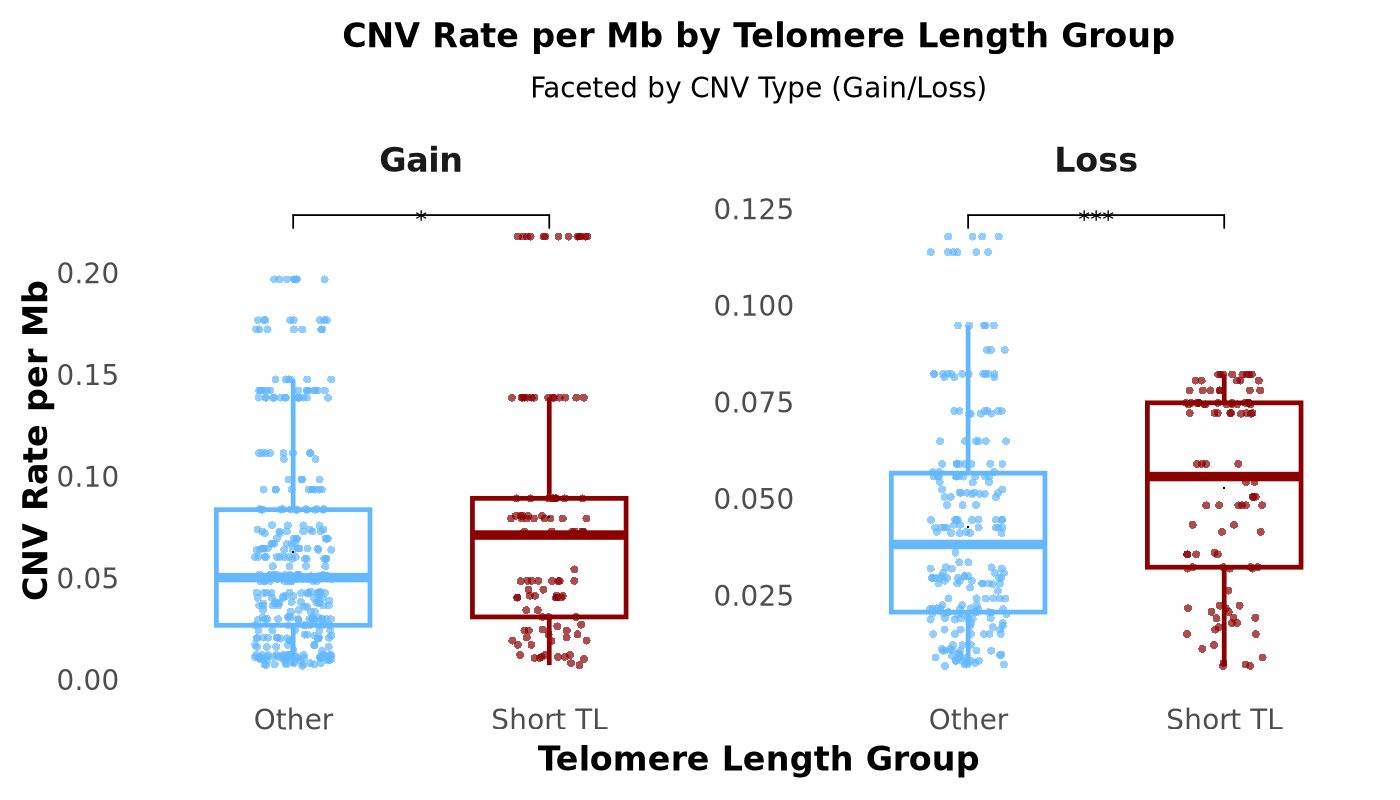

In [158]:
library(ggplot2)
library(ggpubr)
library(dplyr)

# Example for CNV rate
merged_cnv_data <- merged_cnv_data %>%
  mutate(cnv_rate_per_mb = as.numeric(cnv_rate_per_mb)) %>%
  filter(!is.na(cnv_rate_per_mb))

options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)

p_cnv_rate <- ggplot(merged_cnv_data, aes(x = TL_group, y = cnv_rate_per_mb, color = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.4, width = 0.6, size = 0.8) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.7, shape = 16) +
  stat_summary(fun = mean, geom = "point", shape = 15, size = 0, color = "black", fill = "black") +
  facet_wrap(~ Gain_Loss, nrow = 1, scales = "free_y") +
  stat_compare_means(
    method = "wilcox.test",
    aes(group = TL_group),
    label = "p.signif",
    comparisons = list(c("Short TL", "Other")),
    label.y.npc = "top",
    size = 3,
    vjust = 1
  ) +
  scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
  labs(
    title = "CNV Rate per Mb by Telomere Length Group",
    x = "Telomere Length Group",
    y = "CNV Rate per Mb",
    subtitle = "Faceted by CNV Type (Gain/Loss)"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10),
    strip.text = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold", size = 12, hjust = 0.5),
    plot.subtitle = element_text(size = 10, hjust = 0.5),
    legend.position = "none"
  )

print(p_cnv_rate)
# Save CNV rate plot
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data/plots_f2/CNV_rate_by_TL_group.pdf", 
   #    plot = p_cnv_rate, width = 6, height = 4, units = "in", dpi = 300, useDingbats = FALSE)


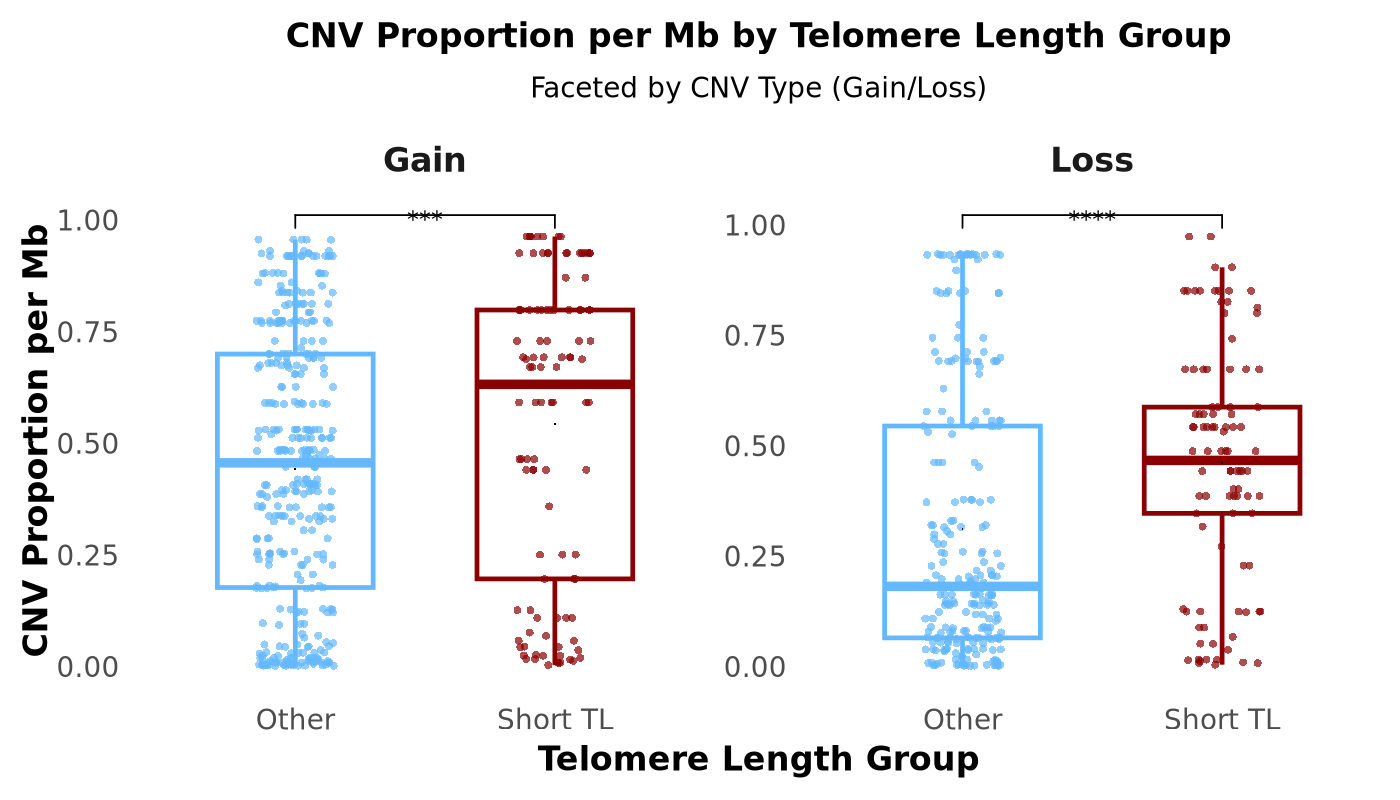

In [159]:
merged_cnv_data <- merged_cnv_data %>%
  mutate(cnv_proportion_per_mb = as.numeric(cnv_proportion_per_mb)) %>%
  filter(!is.na(cnv_proportion_per_mb))

options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 200)

p_cnv_proportion <- ggplot(merged_cnv_data, aes(x = TL_group, y = cnv_proportion_per_mb, color = TL_group)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.4, width = 0.6, size = 0.8) +
  geom_jitter(width = 0.15, size = 1, alpha = 0.7, shape = 16) +
  stat_summary(fun = mean, geom = "point", shape = 15, size = 0, color = "black", fill = "black") +
  facet_wrap(~ Gain_Loss, nrow = 1, scales = "free_y") +
  stat_compare_means(
    method = "wilcox.test",
    aes(group = TL_group),
    label = "p.signif",
    comparisons = list(c("Short TL", "Other")),
    label.y.npc = "top",
    size = 3,
    vjust = 1
  ) +
  scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
  labs(
    title = "CNV Proportion per Mb by Telomere Length Group",
    x = "Telomere Length Group",
    y = "CNV Proportion per Mb",
    subtitle = "Faceted by CNV Type (Gain/Loss)"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold", size = 12),
    axis.text = element_text(size = 10),
    strip.text = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold", size = 12, hjust = 0.5),
    plot.subtitle = element_text(size = 10, hjust = 0.5),
    legend.position = "none"
  )

print(p_cnv_proportion)
# Save CNV proportion plot
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data/plots_f2/CNV_proportion_by_TL_group.pdf", 
      # plot = p_cnv_proportion, width = 6, height = 4, units = "in", dpi = 300, useDingbats = FALSE)


In [160]:
head(merged_cnv_data)

,ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,TL_group
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.339061,0.008042525,0.001609727,chr1q,5051.167,1,q,5.051167,Other
2,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.031877948,0.197875339,chr10q,2732.750,10,q,2.732750,Other
3,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.031877948,0.197875339,chr10q,2732.750,10,q,2.732750,Other
4,2436A,chr10,q,Loss,18.621839,3,94108943,94.108943,0.031877948,0.197875339,chr10q,2732.750,10,q,2.732750,Other
5,2436A,chr15,q,Gain,1.602465,1,82566565,82.566565,0.012111440,0.019408159,chr15q,4111.500,15,q,4.111500,Other
6,2436A,chr18,q,Loss,0.200356,1,62092914,62.092914,0.016104897,0.003226713,chr18q,3629.500,18,q,3.629500,Other


In [161]:
# Subset rows ending with "p"
p_arm <- mat[grep("p$", rownames(mat)), ]

# Subset rows ending with "q"
q_arm <- mat[grep("q$", rownames(mat)), ]


In [162]:
head(p_arm, n=2)
head(q_arm, n=2)

,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1p,5.22100,1.64250,2.3475,6.548000,4.2240,4.01900,5.31100,3.1710,4.1980,3.903,8.373,4.96500,3.577667,3.4245,10.2270,3.43575,7.36425,7.570,4.35200,6.389
chr2p,4.11825,3.43925,3.3950,4.845375,4.4725,6.10825,4.54425,3.2315,4.9195,5.538,8.341,3.29775,4.373500,8.6090,5.8305,5.90250,5.00850,4.248,4.89475,4.374


,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1q,5.051167,3.0865,5.083,3.906333,4.33850,4.7568,4.70475,3.898,6.41925,NA,4.714,4.41925,2.859,6.0195,3.299333,3.9435,8.899333,5.543,5.630,3.09975
chr2q,6.963000,1.9280,NA,5.738000,4.36475,3.2230,5.42350,3.298,NA,3.171,6.927,7.58450,6.082,5.8840,NA,5.1115,2.859000,3.141,7.224,NA


In [163]:
heatmap_combined = rbind(p_arm, q_arm)

In [164]:
# Load required libraries
library(ComplexHeatmap)
library(circlize)

In [165]:
# Define custom scaling function
scale_rows_zscore <- function(mat) {
  row_means <- apply(mat, 1, mean, na.rm = TRUE)
  row_sds <- apply(mat, 1, sd, na.rm = TRUE)
  scaled_mat <- (mat - row_means) / row_sds
  return(scaled_mat)
}

In [166]:
# Scale the data
telomere_scaled <- scale_rows_zscore(p_arm)

In [167]:
max_abs <- max(abs(telomere_scaled), na.rm = TRUE)  # Symmetric range around 0
# Colors: blue (#0571b0) for long, white for average, red (#ca0020) for short
#col_fun <- colorRamp2(c(-max_abs, 0, max_abs), c("darkred", "snow", "white"))
col_fun <- colorRamp2(c(-2, 0, 2), c("darkred", "snow", "white"))

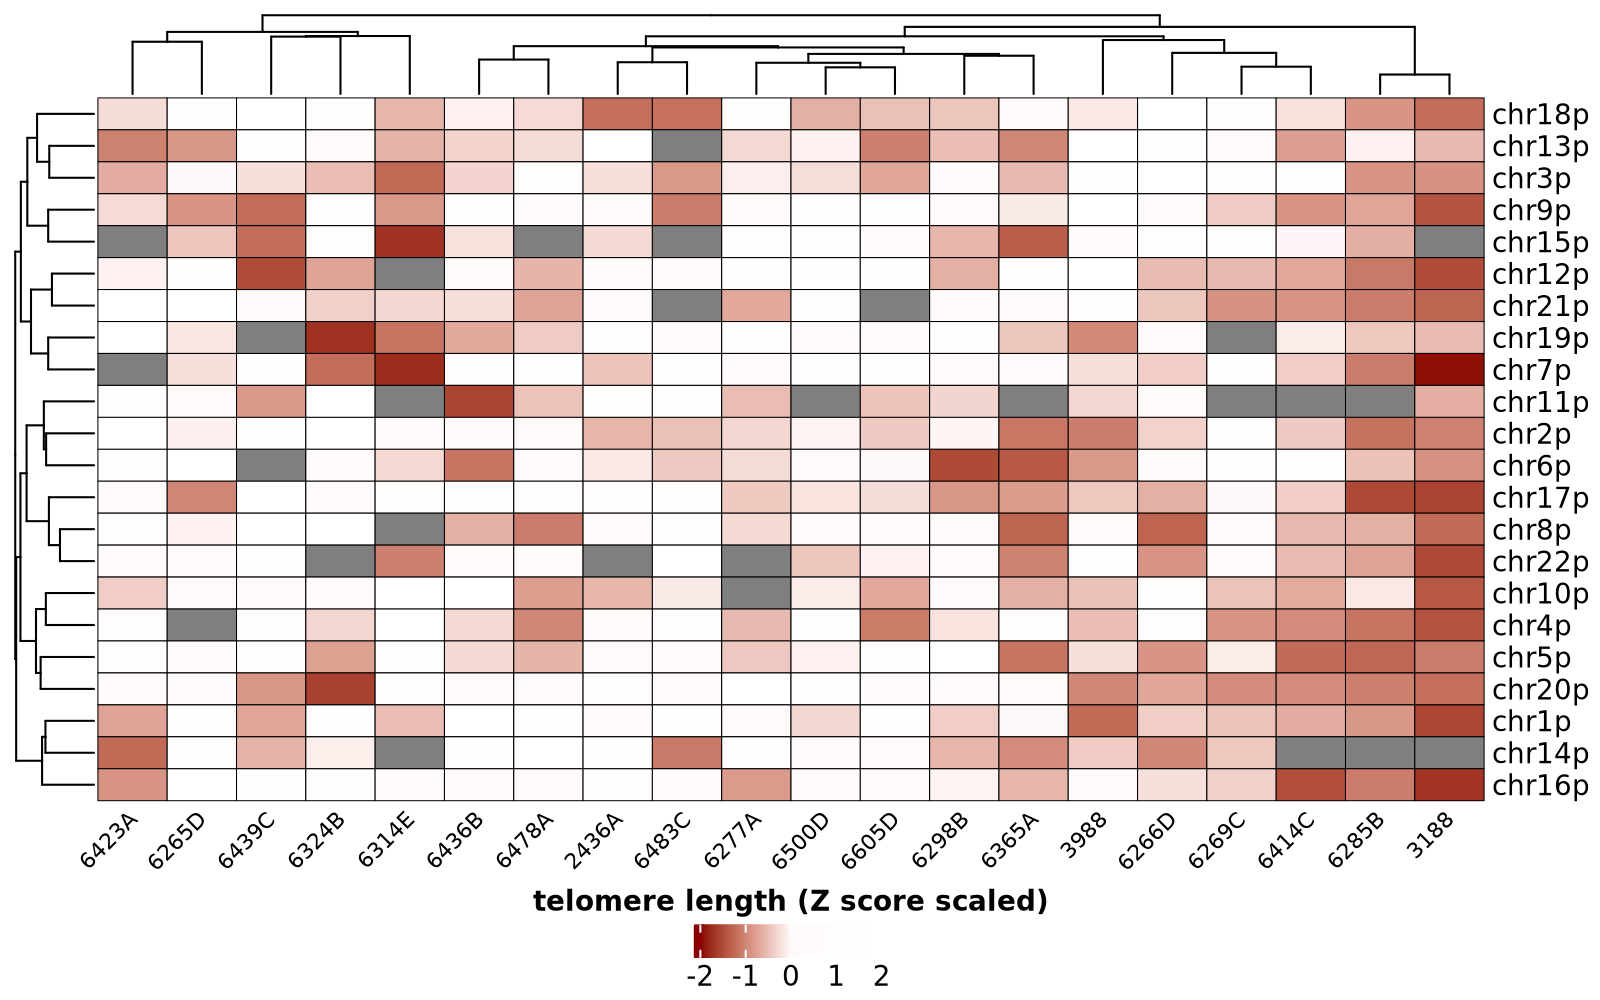

In [168]:
# Load required library (if not already loaded)
library(ComplexHeatmap)
library(grid)  # For gpar()

# Create the heatmap with borders
heatmap_plot <- Heatmap(telomere_scaled,
  name = "p_arm",
  col = col_fun,
  na_col = "grey50",  # NA values in grey
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_side = "right",
  column_names_rot = 45,
  row_names_gp = gpar(fontsize = 10),
  column_names_gp = gpar(fontsize = 8),
  rect_gp = gpar(col = "black", lwd = 0.5),  # Add borders to tiles
  heatmap_legend_param = list(
    title = "telomere length (Z score scaled)",
    title_position = "topcenter",
    direction = "horizontal"
  )
  #width = unit(10, "cm"),  # Adjust width for readability (uncomment if needed)
  #height = unit(4, "cm")   # Compact height for 6 rows (uncomment if needed)
)

# Draw the heatmap
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
draw(heatmap_plot, heatmap_legend_side = "bottom")


In [169]:
# Scale the data
telomere_scaled <- scale_rows_zscore(q_arm)

In [170]:
max_abs <- max(abs(telomere_scaled), na.rm = TRUE)  # Symmetric range around 0
# Colors: blue (#0571b0) for long, white for average, red (#ca0020) for short
#col_fun <- colorRamp2(c(-max_abs, 0, max_abs), c("darkred", "snow", "white"))
col_fun <- colorRamp2(c(-2, 0, 2), c("darkred", "snow", "white"))

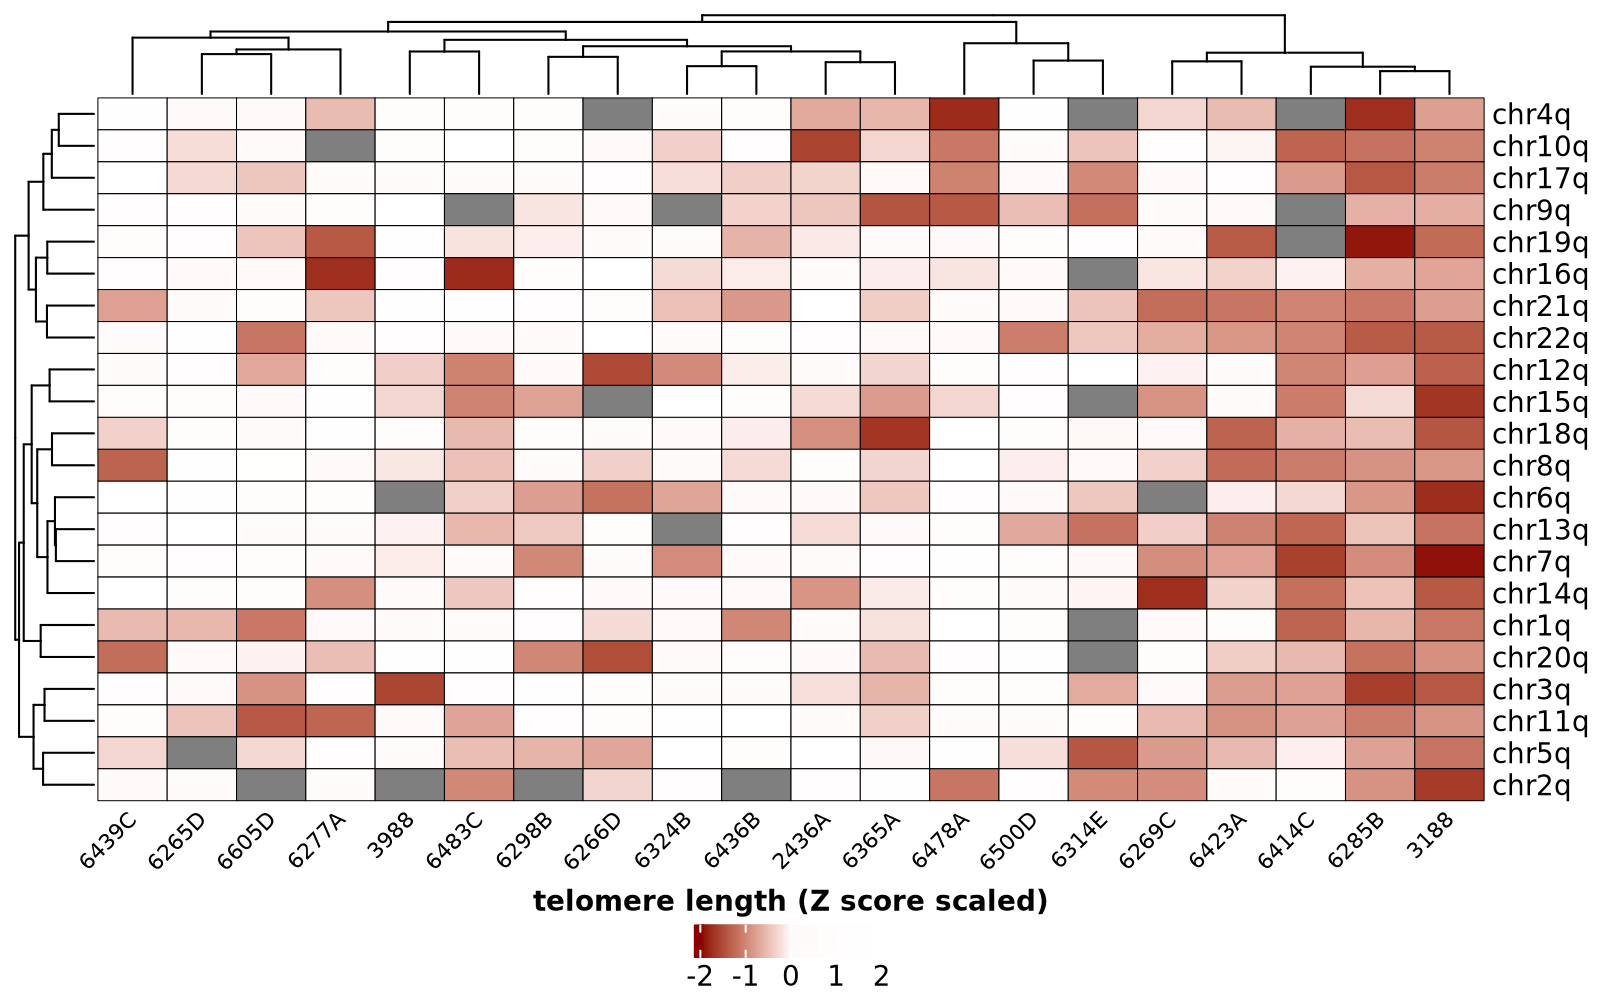

In [171]:
# Load required library (if not already loaded)
library(ComplexHeatmap)
library(grid)  # For gpar()

# Create the heatmap with borders
heatmap_plot <- Heatmap(telomere_scaled,
  name = "q_arm",
  col = col_fun,
  na_col = "grey50",  # NA values in grey
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_side = "right",
  column_names_rot = 45,
  row_names_gp = gpar(fontsize = 10),
  column_names_gp = gpar(fontsize = 8),
  rect_gp = gpar(col = "black", lwd = 0.5),  # Add borders to tiles
  heatmap_legend_param = list(
    title = "telomere length (Z score scaled)",
    title_position = "topcenter",
    direction = "horizontal"
  )
  #width = unit(10, "cm"),  # Adjust width for readability (uncomment if needed)
  #height = unit(4, "cm")   # Compact height for 6 rows (uncomment if needed)
)

# Draw the heatmap
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
draw(heatmap_plot, heatmap_legend_side = "bottom")

In [172]:
heatmap_combined = rbind(p_arm, q_arm)

In [173]:
# Define custom scaling function
scale_rows_zscore <- function(mat) {
  row_means <- apply(mat, 1, mean, na.rm = TRUE)
  row_sds <- apply(mat, 1, sd, na.rm = TRUE)
  scaled_mat <- (mat - row_means) / row_sds
  return(scaled_mat)
}

In [174]:
# Scale the data
telomere_scaled <- scale_rows_zscore(heatmap_combined)


In [175]:
max_abs <- max(abs(telomere_scaled), na.rm = TRUE)  # Symmetric range around 0
# Colors: blue (#0571b0) for long, white for average, red (#ca0020) for short
#col_fun <- colorRamp2(c(-max_abs, 0, max_abs), c("darkred", "snow", "white"))
col_fun <- colorRamp2(c(-2, 0, 2), c("darkred", "snow", "white"))

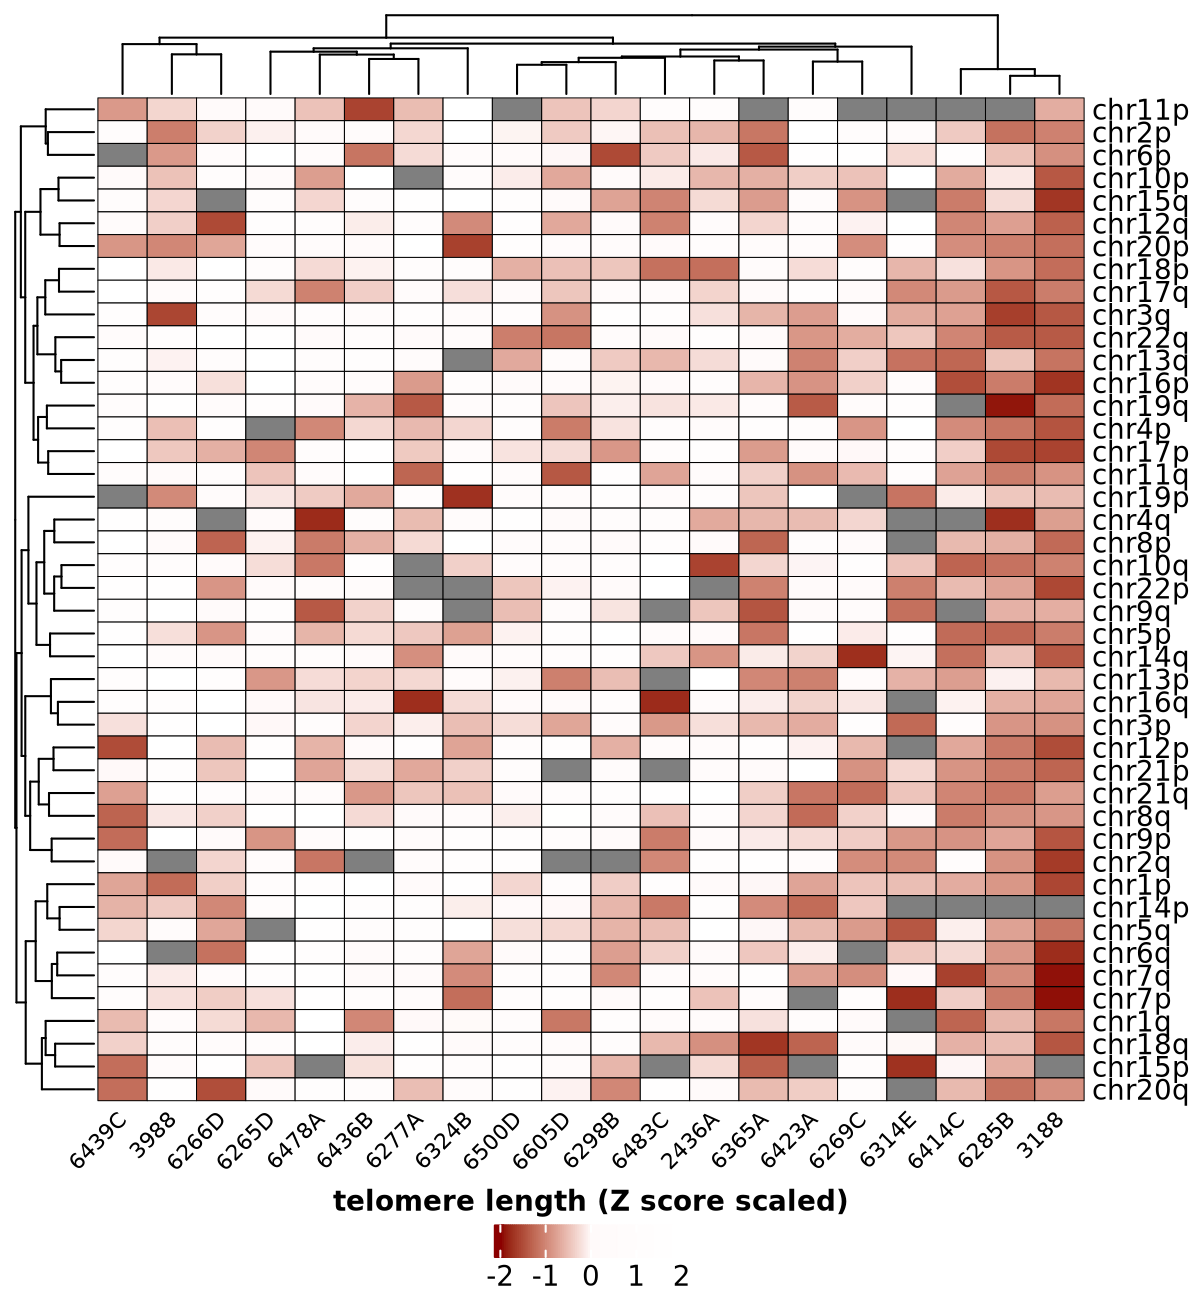

In [176]:
# Load required library (if not already loaded)
library(ComplexHeatmap)
library(grid)  # For gpar()

library(ComplexHeatmap)
library(circlize)

# assuming telomere_scaled and col_fun are already defined...

heatmap_plot <- Heatmap(
  telomere_scaled,
  name = "p_arm",
  col = col_fun,
  na_col = "grey50",  

  # use Euclidean distance + Ward.D2 linkage for rows and columns
  #clustering_distance_rows   = "euclidean",
  #clustering_method_rows     = "ward.D2",
  clustering_distance_columns= "euclidean",
  clustering_method_columns  = "ward.D2",
  show_row_names     = TRUE,
  show_column_names  = TRUE,
  row_names_side     = "right",
  column_names_rot   = 45,
  row_names_gp       = gpar(fontsize = 10),
  column_names_gp    = gpar(fontsize = 8),

  rect_gp            = gpar(col = "black", lwd = 0.5),
  heatmap_legend_param = list(
    title           = "telomere length (Z score scaled)",
    title_position  = "topcenter",
    direction       = "horizontal"
  )
  # width = unit(10, "cm"),
  # height = unit(4, "cm")
)


# Draw the heatmap
options(repr.plot.width = 6, repr.plot.height = 6.5, repr.plot.res = 200)
draw(heatmap_plot, heatmap_legend_side = "bottom")


In [177]:
heatmap_combined = rbind(p_arm, q_arm)

In [178]:
head(heatmap_combined)

,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1p,5.22100,1.642500,2.347500,6.548000,4.224000,4.01900,5.311000,3.17100,4.1980,3.903,8.373,4.965000,3.577667,3.4245,10.227000,3.435750,7.364250,7.57000,4.35200,6.38900
chr2p,4.11825,3.439250,3.395000,4.845375,4.472500,6.10825,4.544250,3.23150,4.9195,5.538,8.341,3.297750,4.373500,8.6090,5.830500,5.902500,5.008500,4.24800,4.89475,4.37400
chr3p,4.73920,2.890500,10.037500,5.329500,12.829500,9.17100,5.097900,2.98500,5.9785,1.922,3.953,3.834333,7.371250,3.5410,4.486500,4.767667,7.234000,3.06000,4.69800,3.37975
chr4p,5.78825,2.557833,4.202000,NA,6.912000,3.55950,4.112500,3.05775,4.7370,8.268,4.548,6.984000,3.407417,6.5230,4.571250,7.232000,3.353333,6.78725,6.66550,3.16500
chr5p,6.54575,3.681000,5.688667,7.076000,4.185500,5.93250,5.226833,3.22800,10.7335,9.230,4.419,3.540000,3.302000,9.7060,5.587500,9.609000,4.829500,6.91000,6.06050,8.95125
chr6p,4.04850,2.707500,2.850250,7.669250,4.795375,6.96300,3.839667,3.46300,1.6410,3.820,5.239,1.875500,6.200000,6.8080,2.295167,NA,5.004000,3.58050,4.44100,4.24975


In [179]:
data_dir = '/home/mjehangir/glioma_manuscript/fig2/'

pdf 
  2

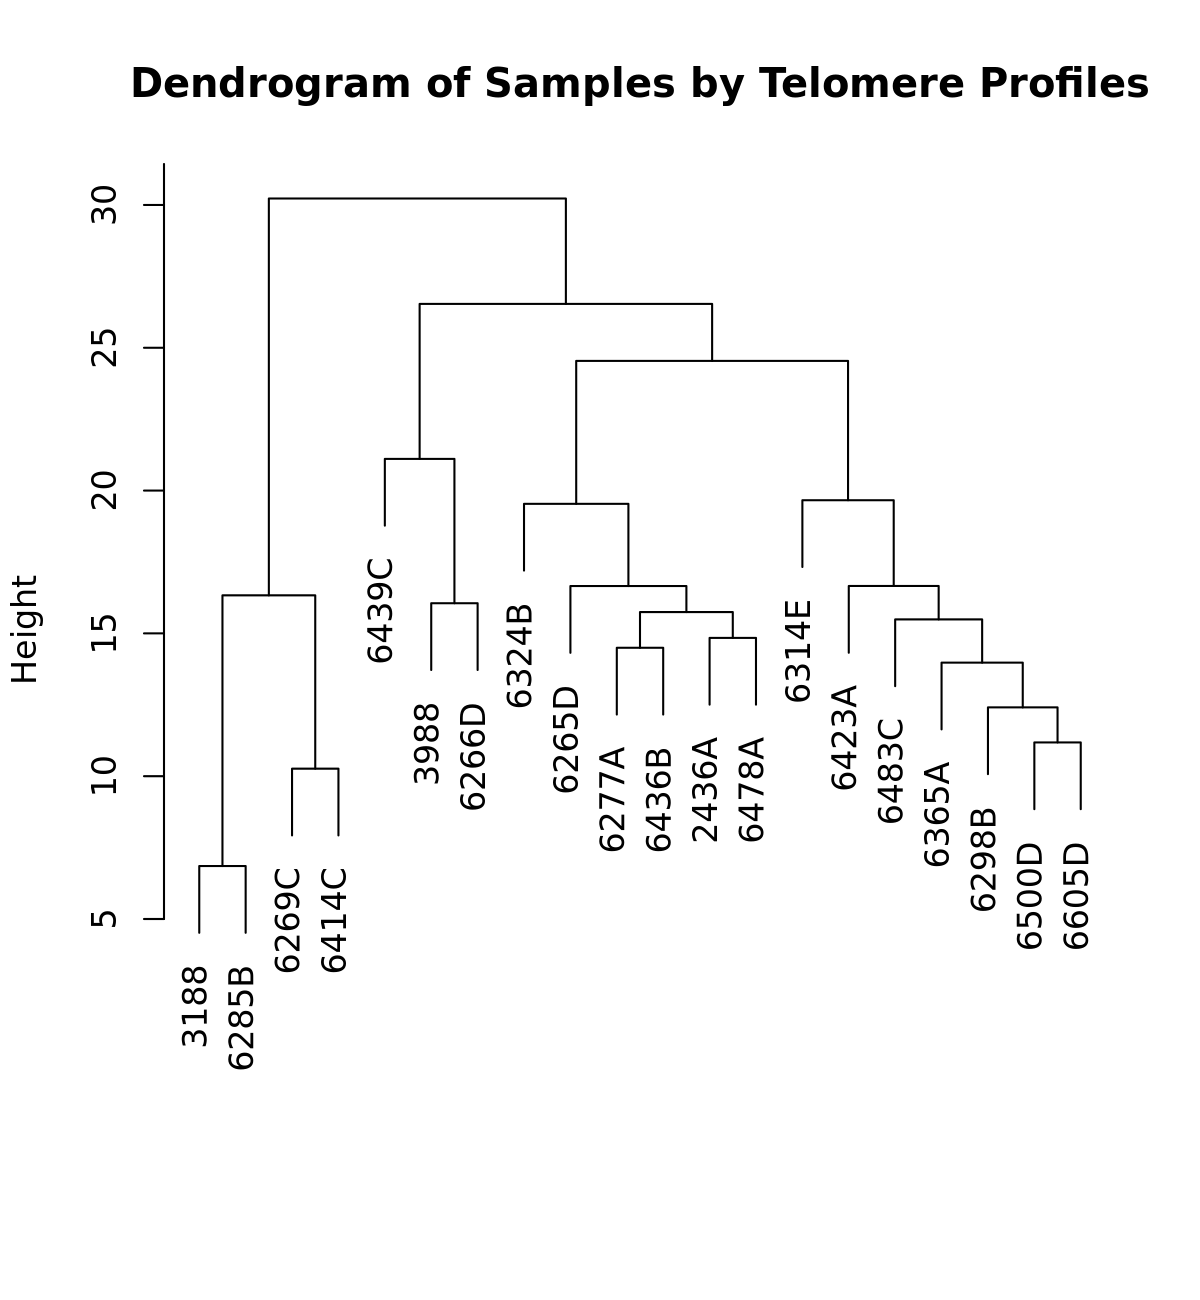

In [180]:
#---------------------------------------------
# 1. Load required libraries
#---------------------------------------------
# install.packages(c("tidyverse", "ggplot2"))  # if not already installed
library(tidyverse)
library(ggplot2)


#---------------------------------------------
# 3. Compute hierarchical clustering of samples
#    (samples are columns → so we transpose)
#---------------------------------------------
dist_mat <- dist(t(heatmap_combined), method = "euclidean")
hc       <- hclust(dist_mat, method = "ward.D2")

# Optional: visualize dendrogram to choose number of clusters
plot(hc, main = "Dendrogram of Samples by Telomere Profiles", xlab = "", sub = "")

#---------------------------------------------
# 4. Cut the tree into k clusters
#    Here we'll use k = 2 (low vs. other)
#---------------------------------------------
k <- 5
clusters <- cutree(hc, k = k)  # a named integer vector of length 20

#---------------------------------------------
# 5. Identify which cluster has the lowest
#    mean telomere size (averaged across rows)
#---------------------------------------------
# compute each sample’s mean telomere size
mean_tel <- colMeans(heatmap_combined, na.rm = TRUE)

# compute average per cluster
cluster_means <- tapply(mean_tel, clusters, mean)

# pick the cluster with the lowest mean
low_cluster <- which.min(cluster_means)

# build a named factor/vector of “Low” vs. “Other”
sample_group <- ifelse(clusters == low_cluster, "Low", "Other")
sample_group <- factor(sample_group, levels = c("Low","Other"))

#---------------------------------------------
# 6. Melt data into long format and add group
#---------------------------------------------
df_long <- as.data.frame(heatmap_combined) %>%
  rownames_to_column(var = "Chromosome") %>%
  pivot_longer(
    cols      = -Chromosome,
    names_to  = "Sample",
    values_to = "TelomereSize"
  ) %>%
  mutate(Group = sample_group[Sample])

# Save dendrogram to a PDF file
pdf("/scratch/mjehangir/manuscript_figures/manuscript_data/plots_f2/dendrogram_telomere_profiles.pdf", width = 7, height = 5)
plot(hc, main = "Dendrogram of Samples by Telomere Profiles", xlab = "", sub = "")
dev.off()


In [181]:
head(heatmap_combined)

,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1p,5.22100,1.642500,2.347500,6.548000,4.224000,4.01900,5.311000,3.17100,4.1980,3.903,8.373,4.965000,3.577667,3.4245,10.227000,3.435750,7.364250,7.57000,4.35200,6.38900
chr2p,4.11825,3.439250,3.395000,4.845375,4.472500,6.10825,4.544250,3.23150,4.9195,5.538,8.341,3.297750,4.373500,8.6090,5.830500,5.902500,5.008500,4.24800,4.89475,4.37400
chr3p,4.73920,2.890500,10.037500,5.329500,12.829500,9.17100,5.097900,2.98500,5.9785,1.922,3.953,3.834333,7.371250,3.5410,4.486500,4.767667,7.234000,3.06000,4.69800,3.37975
chr4p,5.78825,2.557833,4.202000,NA,6.912000,3.55950,4.112500,3.05775,4.7370,8.268,4.548,6.984000,3.407417,6.5230,4.571250,7.232000,3.353333,6.78725,6.66550,3.16500
chr5p,6.54575,3.681000,5.688667,7.076000,4.185500,5.93250,5.226833,3.22800,10.7335,9.230,4.419,3.540000,3.302000,9.7060,5.587500,9.609000,4.829500,6.91000,6.06050,8.95125
chr6p,4.04850,2.707500,2.850250,7.669250,4.795375,6.96300,3.839667,3.46300,1.6410,3.820,5.239,1.875500,6.200000,6.8080,2.295167,NA,5.004000,3.58050,4.44100,4.24975


In [182]:
head(heatmap_combined)

,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1p,5.22100,1.642500,2.347500,6.548000,4.224000,4.01900,5.311000,3.17100,4.1980,3.903,8.373,4.965000,3.577667,3.4245,10.227000,3.435750,7.364250,7.57000,4.35200,6.38900
chr2p,4.11825,3.439250,3.395000,4.845375,4.472500,6.10825,4.544250,3.23150,4.9195,5.538,8.341,3.297750,4.373500,8.6090,5.830500,5.902500,5.008500,4.24800,4.89475,4.37400
chr3p,4.73920,2.890500,10.037500,5.329500,12.829500,9.17100,5.097900,2.98500,5.9785,1.922,3.953,3.834333,7.371250,3.5410,4.486500,4.767667,7.234000,3.06000,4.69800,3.37975
chr4p,5.78825,2.557833,4.202000,NA,6.912000,3.55950,4.112500,3.05775,4.7370,8.268,4.548,6.984000,3.407417,6.5230,4.571250,7.232000,3.353333,6.78725,6.66550,3.16500
chr5p,6.54575,3.681000,5.688667,7.076000,4.185500,5.93250,5.226833,3.22800,10.7335,9.230,4.419,3.540000,3.302000,9.7060,5.587500,9.609000,4.829500,6.91000,6.06050,8.95125
chr6p,4.04850,2.707500,2.850250,7.669250,4.795375,6.96300,3.839667,3.46300,1.6410,3.820,5.239,1.875500,6.200000,6.8080,2.295167,NA,5.004000,3.58050,4.44100,4.24975


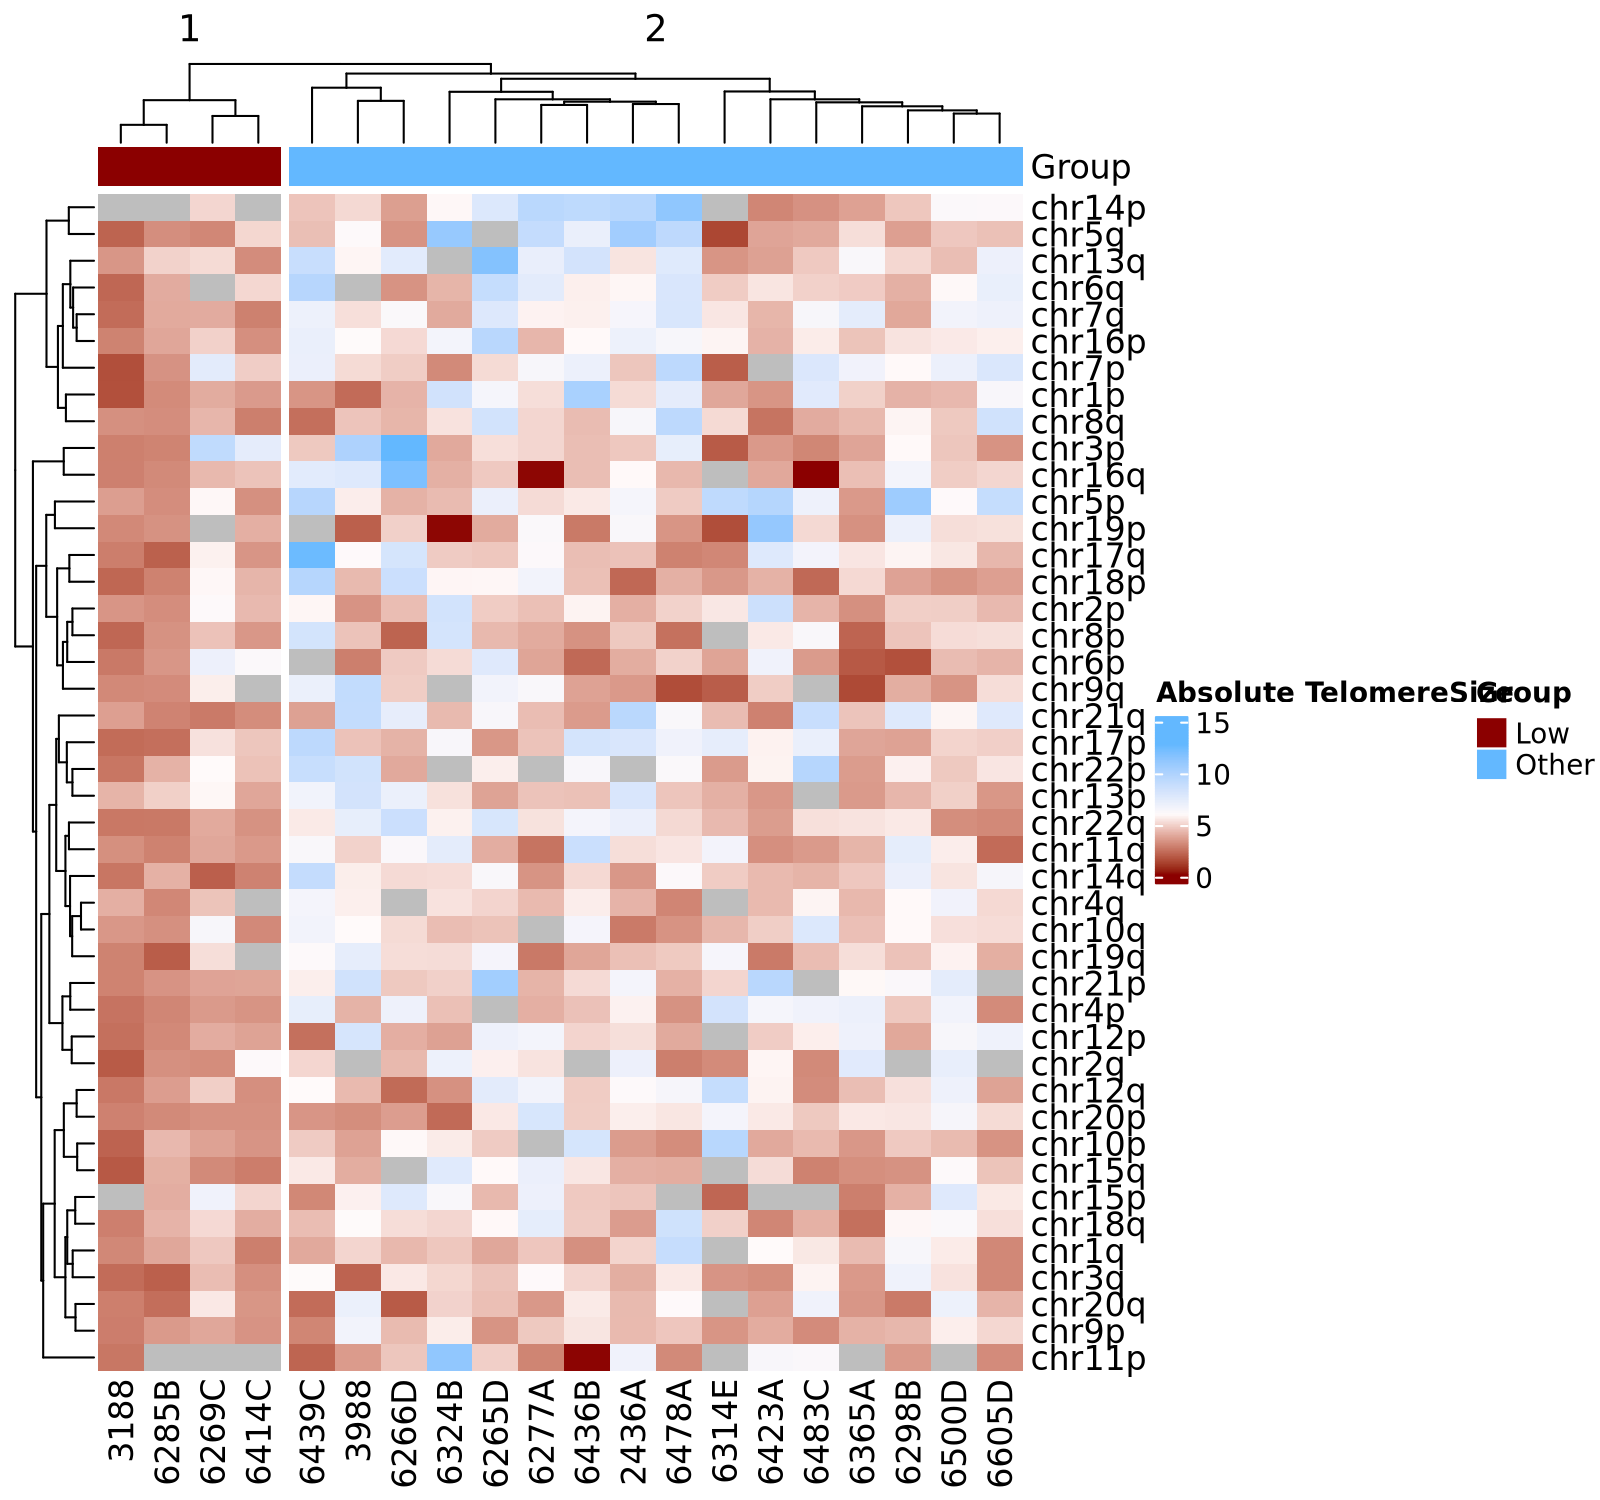

In [184]:
library(ComplexHeatmap)
library(circlize)  

# 1) create a color function: red at min, white at max
#rng <- range(heatmap_combined, na.rm = TRUE)
#col_fun <- colorRamp2(rng, c("indianred4", "white"))

col_fun <- colorRamp2(c(min(heatmap_combined, na.rm = TRUE), 6, max(heatmap_combined, na.rm = TRUE)),
                    c("darkred", "snow", "steelblue1"))

#col_fun <- colorRamp2("indianred4", "white")


# 2) convert your hclust into a dendrogram
col_dend <- as.dendrogram(hc)
options(repr.plot.width = 8, repr.plot.height = 7.5, repr.plot.res = 200)

#pdf(file = "heatmap_clustering_telomere_length_absolute.pdf", width = 8, height = 7.5)

# 3) draw the heatmap with your col_fun
Heatmap(
  heatmap_combined,
  name               = "Absolute TelomereSize",
  col                = col_fun,        # ← use red→white mapping :contentReference[oaicite:0]{index=0}
  
  # rows: hierarchical as before
  cluster_rows             = TRUE,
  clustering_distance_rows = "euclidean",
  clustering_method_rows   = "ward.D2",
  
  # columns: your precomputed dendrogram, split into 2
  cluster_columns    = col_dend,
  column_split       = 2,

  show_column_dend   = TRUE,
  
  # annotation bar for “Low” vs. “Other”
  top_annotation     = HeatmapAnnotation(
    Group = sample_group,
    col   = list(Group = c(Low = "darkred", Other = "steelblue1"))
  )
)
#dev.off()

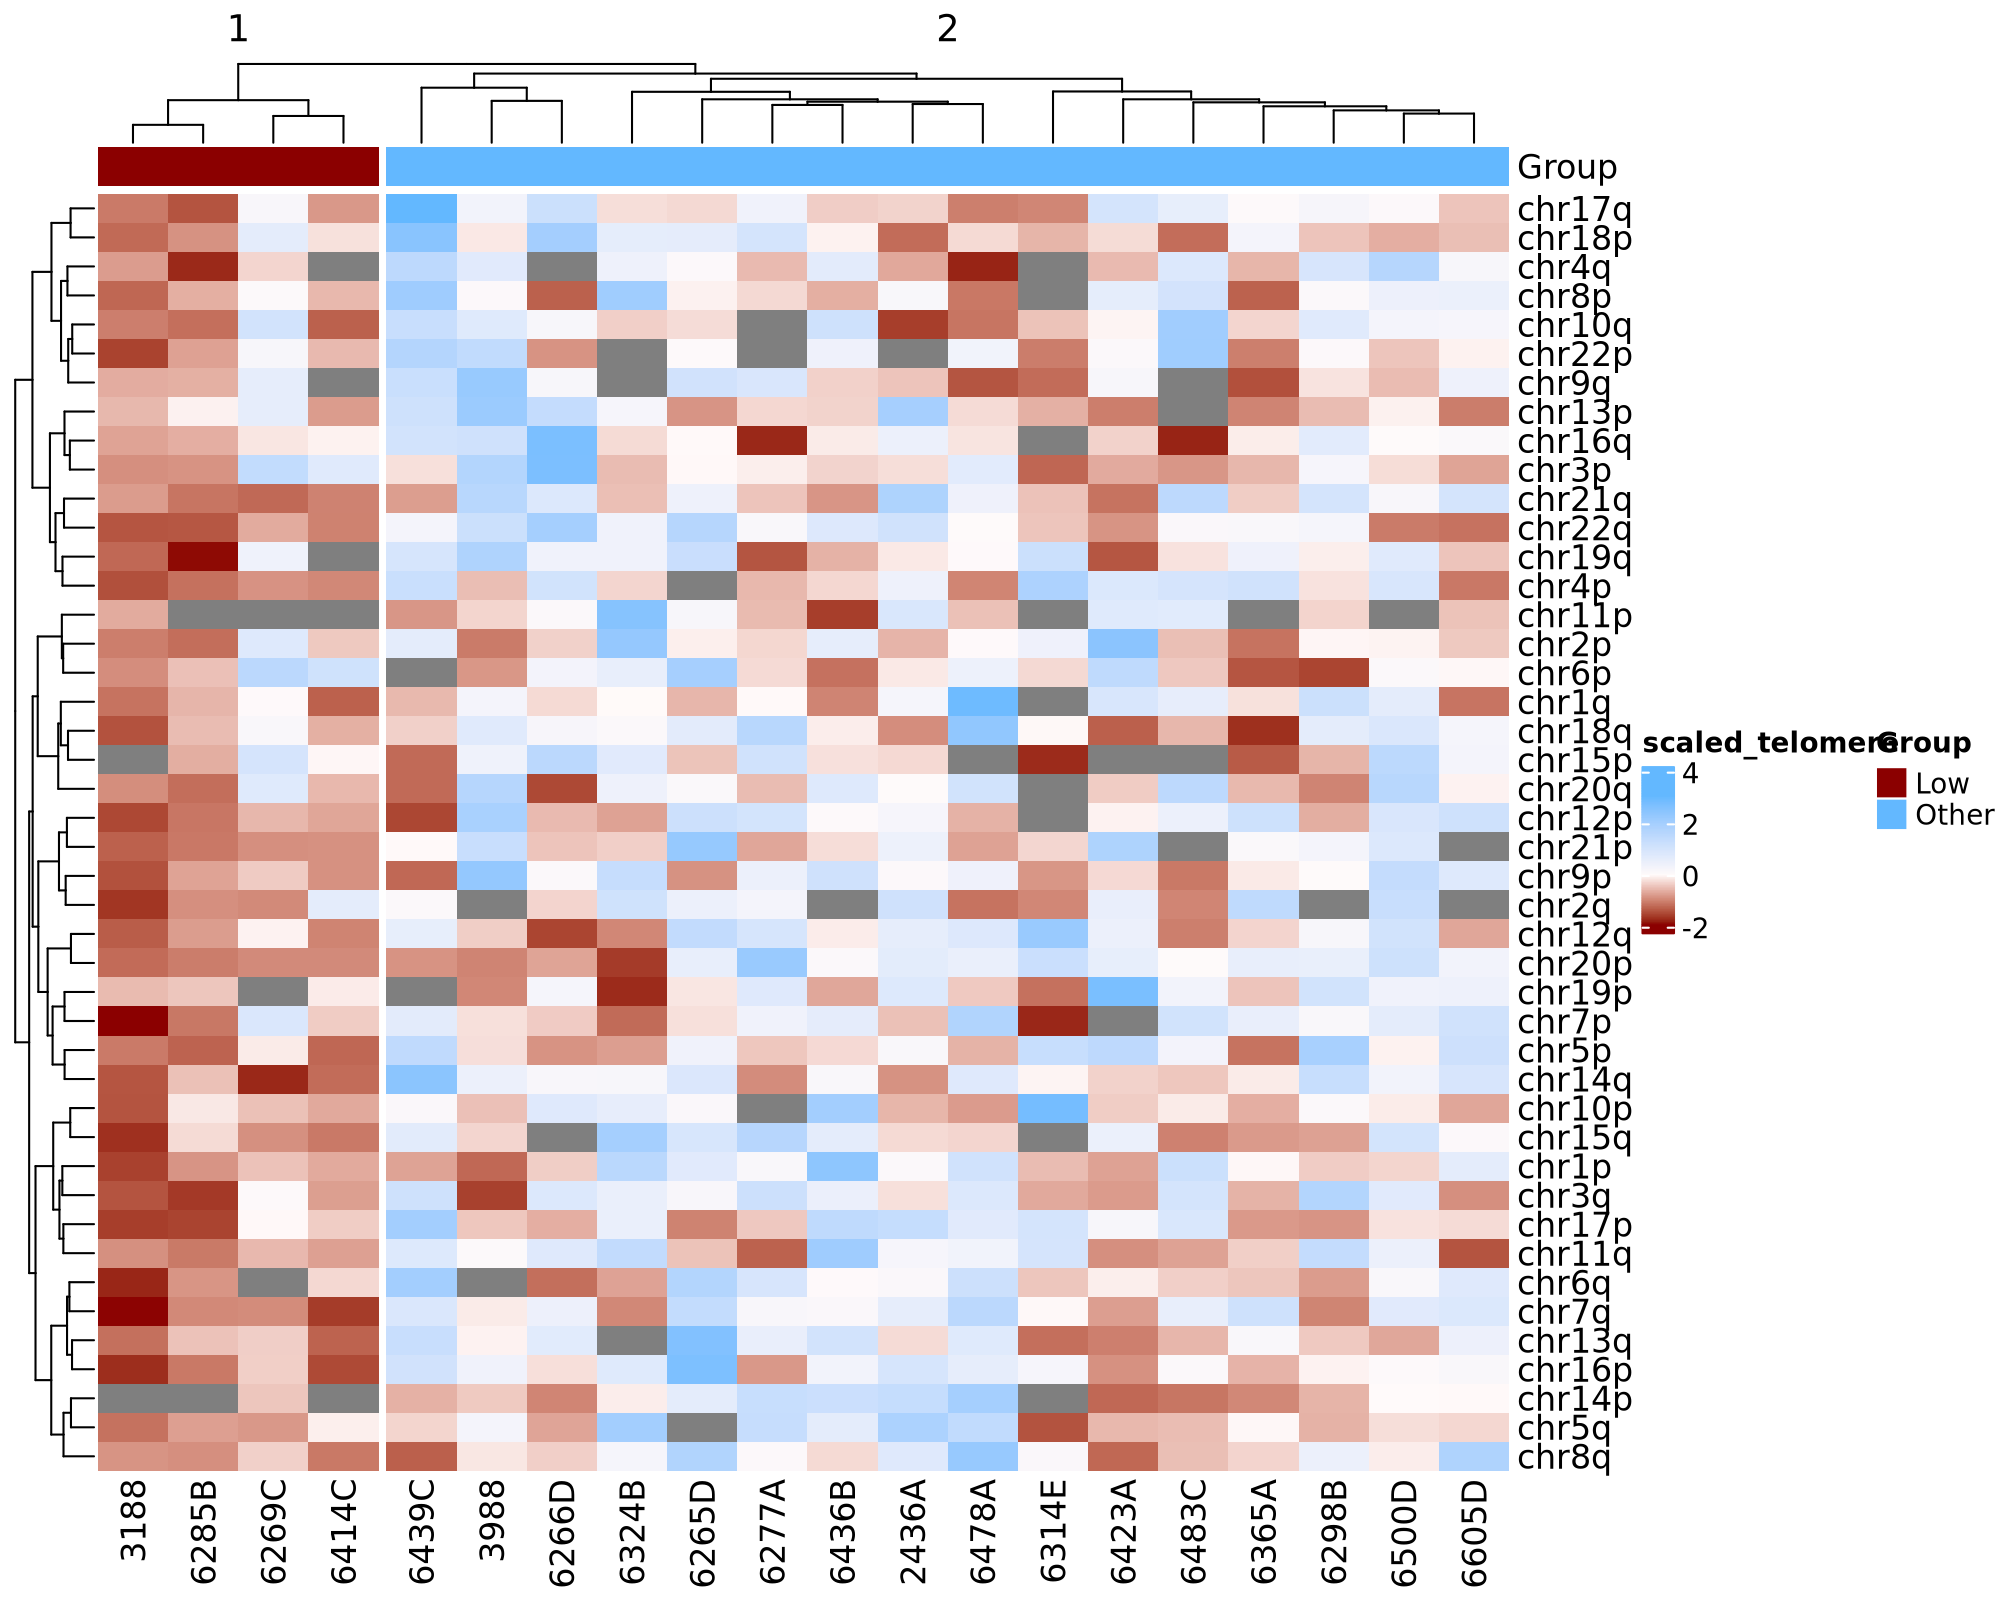

In [186]:
# 1) row-wise z-score: center & scale each row
heatmap_z_row <- t( scale( t(heatmap_combined), 
                           center = TRUE, 
                           scale  = TRUE ) )

mat_to_plot <- heatmap_z_row

# define a diverging color ramp around zero:
col_fun_z <- colorRamp2(
  c(min(mat_to_plot, na.rm=TRUE), 0, max(mat_to_plot, na.rm=TRUE)),
  c("darkred", "snow", "steelblue1")            # high (positive z) — you can change to another color if you like
)

options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 200)

Heatmap(
  mat_to_plot,
  name               = "scaled_telomere",
    show_row_names = TRUE,
    na_col = "grey50",
  col                = col_fun_z,
  cluster_rows             = TRUE,
  clustering_distance_rows = "euclidean",
  clustering_method_rows   = "ward.D2",
  cluster_columns    = col_dend,
  column_split       = 2,
  show_column_dend   = TRUE,
  top_annotation     = HeatmapAnnotation(
    Group = sample_group,
    col   = list(Group = c(Low = "darkred", Other = "steelblue1"))
  )
)


In [57]:
library(ComplexHeatmap)
library(circlize)
library(grid)   # for gpar()

#pdf(file = "/scratch/mjehangir/manuscript_figures/manuscript_data//plots_f2/heatmap_clustering_telomere_length_scaled.pdf", width = 8, height = 7.5)

options(repr.plot.width = 8, repr.plot.height = 7.5, repr.plot.res = 200)
Heatmap(
  mat_to_plot,
  name               = "scaled_telomere",
  show_row_names     = TRUE,
  na_col             = "grey50",
  col                = col_fun_z,
  rect_gp            = gpar(col = "black", lwd = 0.3),   # ← black border, line-width = 1
  cluster_rows             = TRUE,
  clustering_distance_rows = "euclidean",
  clustering_method_rows   = "ward.D2",
  cluster_columns    = col_dend,
  column_split       = 2,
  show_column_dend   = TRUE,
  top_annotation     = HeatmapAnnotation(
    Group = sample_group,
    col   = list(Group = c(Low = "darkred", Other = "steelblue1"))
  )
)
#dev.off()

pdf 
  2

Warning message:
“Removed 49 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 49 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 49 rows containing non-finite outside the scale range
(`stat_signif()`).”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”


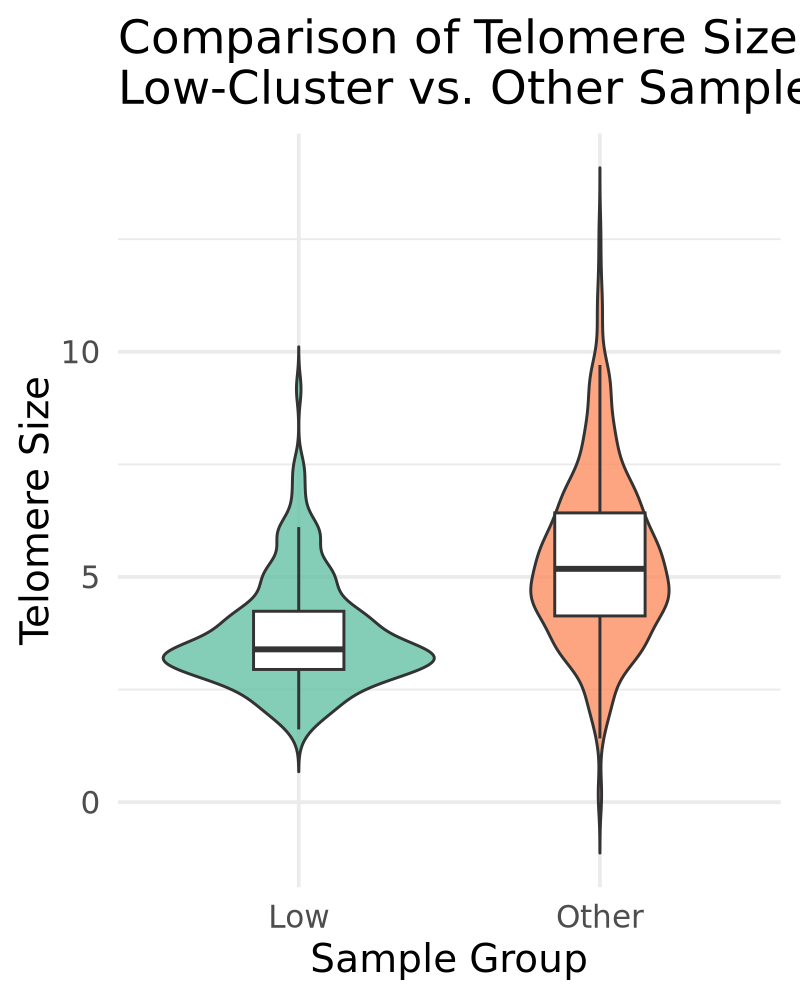

In [189]:
library(ggplot2)

# install.packages("ggpubr")  # if not already installed
library(ggplot2)
library(ggpubr)

# Define the pair to compare
my_comparisons <- list(c("short", "Other"))

options(repr.plot.width = 4, repr.plot.height = 5, repr.plot.res = 200)

p <- ggplot(df_long, aes(x = Group, y = TelomereSize, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.8) +
  # white boxplot inside
  geom_boxplot(width = 0.3, fill = "white", outlier.shape = NA) +
  # jittered points (optional)
  #geom_jitter(width = 0.15, alpha = 0.5, size = 1) +
  # add p‑value from t‑test comparing Low vs Other
  stat_compare_means(
    comparisons = my_comparisons,
    method      = "t.test",
    label       = "p.format",
    tip.length  = 0.02
  ) +
  scale_fill_brewer(palette = "Set2") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Comparison of Telomere Sizes\nLow‑Cluster vs. Other Samples",
    x     = "Sample Group",
    y     = "Telomere Size"
  ) +
  theme(legend.position = "none")
print(p)
#ggsave("/scratch/mjehangir/manuscript_figures/manuscript_data//plots_f2/telomere_violin_plot.pdf", plot = p, width = 4, height = 5)

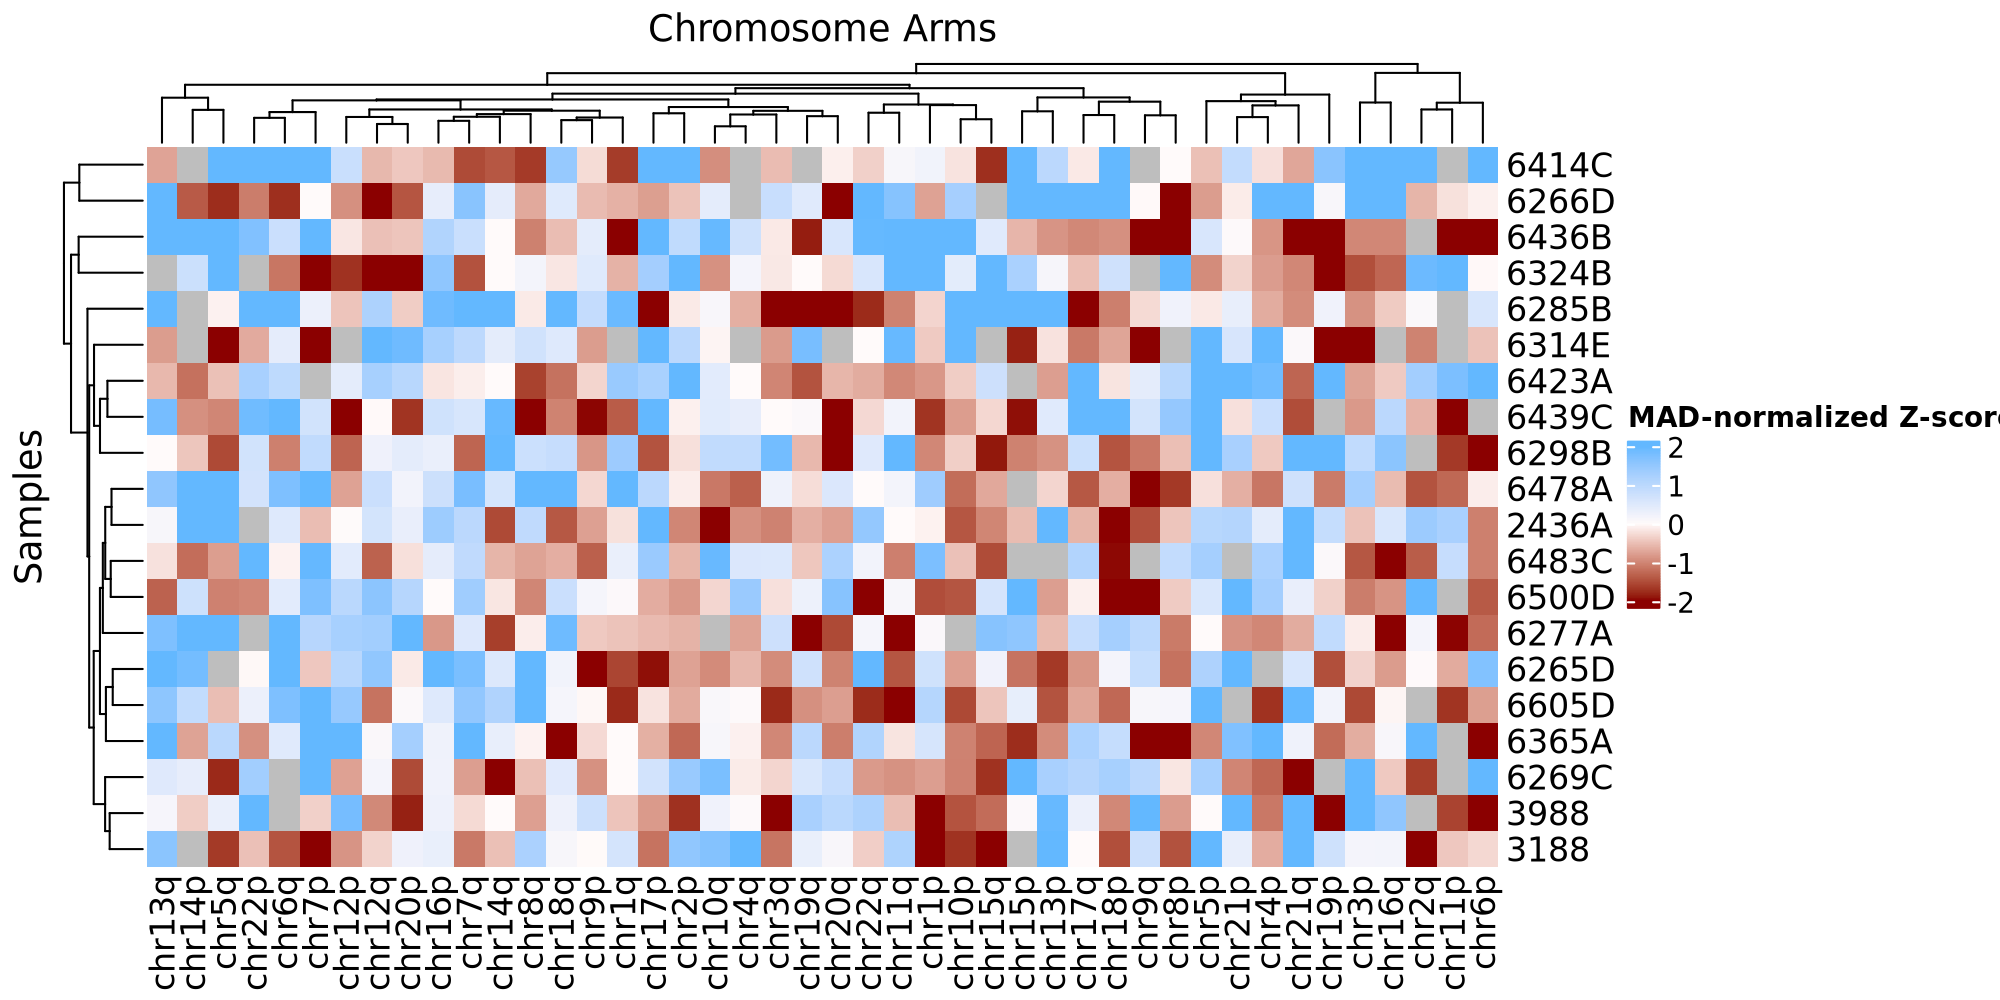

In [229]:

# Normalize using MAD within each sample
telomere_df <- df %>%
  mutate(chr_arm = chr) %>%
  group_by(Sample_prefix) %>%
  mutate(
    median_TL = median(final_average_TL_p75, na.rm = TRUE),
    mad_TL = mad(final_average_TL_p75, constant = 1, na.rm = TRUE),
    norm_TL = (final_average_TL_p75 - median_TL) / mad_TL
  ) %>%
  ungroup()



# Matrix for heatmap (samples = rows, chr_arms = columns)
heatmap_matrix <- telomere_df %>%
  select(Sample_prefix, chr_arm, norm_TL) %>%
  pivot_wider(names_from = chr_arm, values_from = norm_TL) %>%
  arrange(Sample_prefix) %>%
  column_to_rownames(var = "Sample_prefix")

heatmap_matrix <- as.matrix(heatmap_matrix)
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

# Heatmap color scale
heat_colors <- colorRamp2(c(-2, 0, 2), c("darkred", "snow", "steelblue1"))

# Create the heatmap
ht <- Heatmap(
  heatmap_matrix,
  name = "MAD-Normalized TL",
  col = heat_colors,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_title = "Samples",
  column_title = "Chromosome Arms",
  heatmap_legend_param = list(title = "MAD-normalized Z-scores")
)

# Output
draw(ht)


[1] 44 20
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
    126    3584    4782    5049    6084   12830      49 


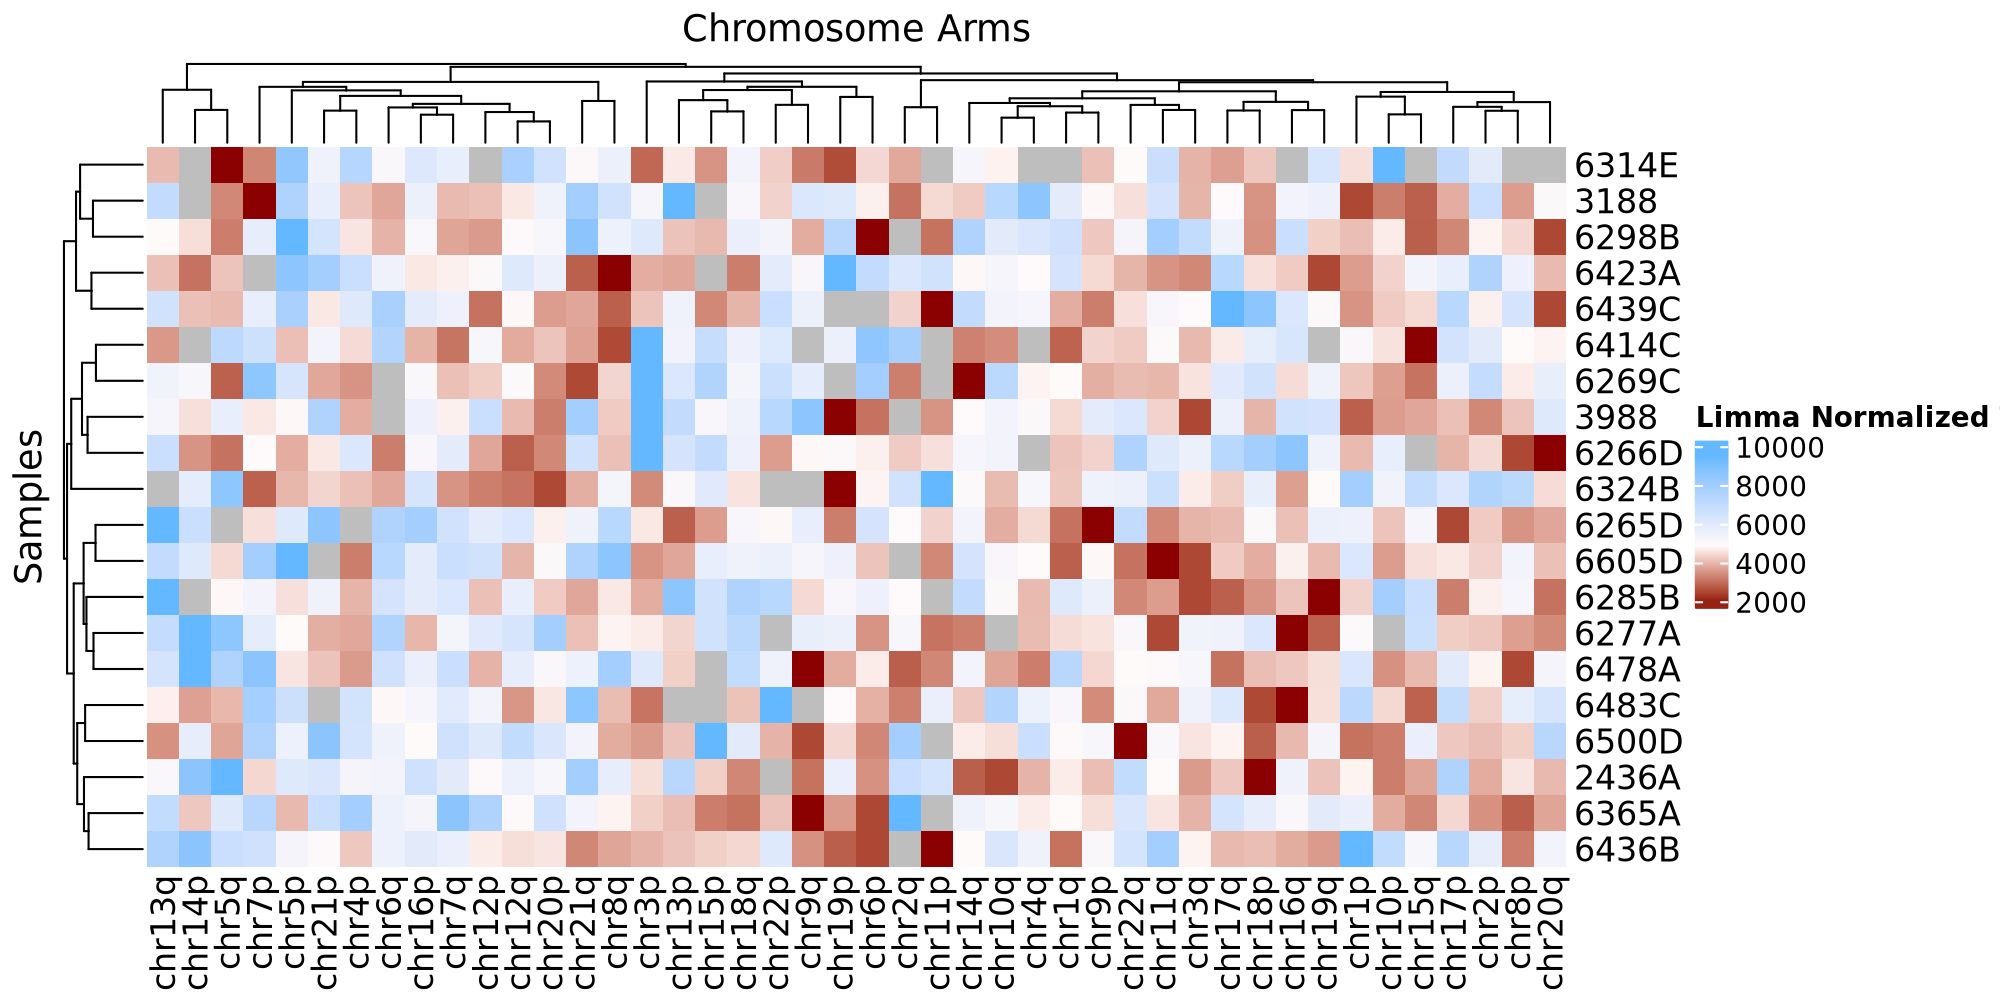

In [193]:

# Prepare matrix: rows = chromosome arms, columns = samples
tel_matrix <- df %>%
  select(Sample_prefix, chr, final_average_TL_p75) %>%
  pivot_wider(names_from = Sample_prefix, values_from = final_average_TL_p75) %>%
  column_to_rownames(var = "chr") %>%
  as.matrix()

# Check matrix dimensions and basic stats
print(dim(tel_matrix))
print(summary(as.vector(tel_matrix)))

# Apply limma normalization across columns (samples)
tel_matrix_norm <- normalizeBetweenArrays(tel_matrix, method = "quantile")

# Transpose so rows = samples, columns = chromosome arms for heatmap
heatmap_matrix <- t(tel_matrix_norm)

# Check range for color breaks
val_min <- min(heatmap_matrix, na.rm = TRUE)
val_median <- median(heatmap_matrix, na.rm = TRUE)
val_max <- max(heatmap_matrix, na.rm = TRUE)

# Fix if min, median, max are not distinct
if(val_min == val_median & val_median == val_max){
  val_max <- val_max + 1e-6  # Add small offset to max to avoid error
}

# Define color scale
heat_colors <- colorRamp2(
  c(val_min, val_median, val_max),
  c("darkred", "snow", "steelblue1")
)

# Plot heatmap
Heatmap(
  heatmap_matrix,
  name = "Limma Normalized TL",
  col = heat_colors,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_title = "Samples",
  column_title = "Chromosome Arms"
)


In [226]:
head(tel_matrix)

,2436A,3188,3988,6265D,6266D,6269C,6277A,6285B,6298B,6314E,6324B,6365A,6414C,6423A,6436B,6439C,6478A,6483C,6500D,6605D
chr1p,5221.000,1642.50,2347.500,6548.000,4224.00,4019.000,5311.00,3171.00,4198.00,3903.0,8373,4965.000,3577.667,3424.500,10227.000,3435.750,7364.250,7570.0,4352.00,6389.00
chr1q,5051.167,3086.50,5083.000,3906.333,4338.50,4756.800,4704.75,3898.00,6419.25,NA,4714,4419.250,2859.000,6019.500,3299.333,3943.500,8899.333,5543.0,5630.00,3099.75
chr2p,4118.250,3439.25,3395.000,4845.375,4472.50,6108.250,4544.25,3231.50,4919.50,5538.0,8341,3297.750,4373.500,8609.000,5830.500,5902.500,5008.500,4248.0,4894.75,4374.00
chr2q,6963.000,1928.00,NA,5738.000,4364.75,3223.000,5423.50,3298.00,NA,3171.0,6927,7584.500,6082.000,5884.000,NA,5111.500,2859.000,3141.0,7224.00,NA
chr3p,4739.200,2890.50,10037.500,5329.500,12829.50,9171.000,5097.90,2985.00,5978.50,1922.0,3953,3834.333,7371.250,3541.000,4486.500,4767.667,7234.000,3060.0,4698.00,3379.75
chr3q,4078.050,2360.80,2135.214,4617.500,5562.00,4462.125,6069.00,2050.25,6844.50,3415.5,5117,3536.600,3291.500,3244.875,5081.417,6033.267,5576.500,5834.5,5411.50,3096.25


In [ ]:
How to Choose for Telomere Analysis?

Detect extreme short/long telomeres	Z-score
Reduce outlier impact, see overall trends	MAD normalization
Correct for batch/sample technical bias	Quantile normalization (limma)
Compare TL relative to a baseline	RTL calculation
Stabilize variance/skewed data	Log transform + normalization

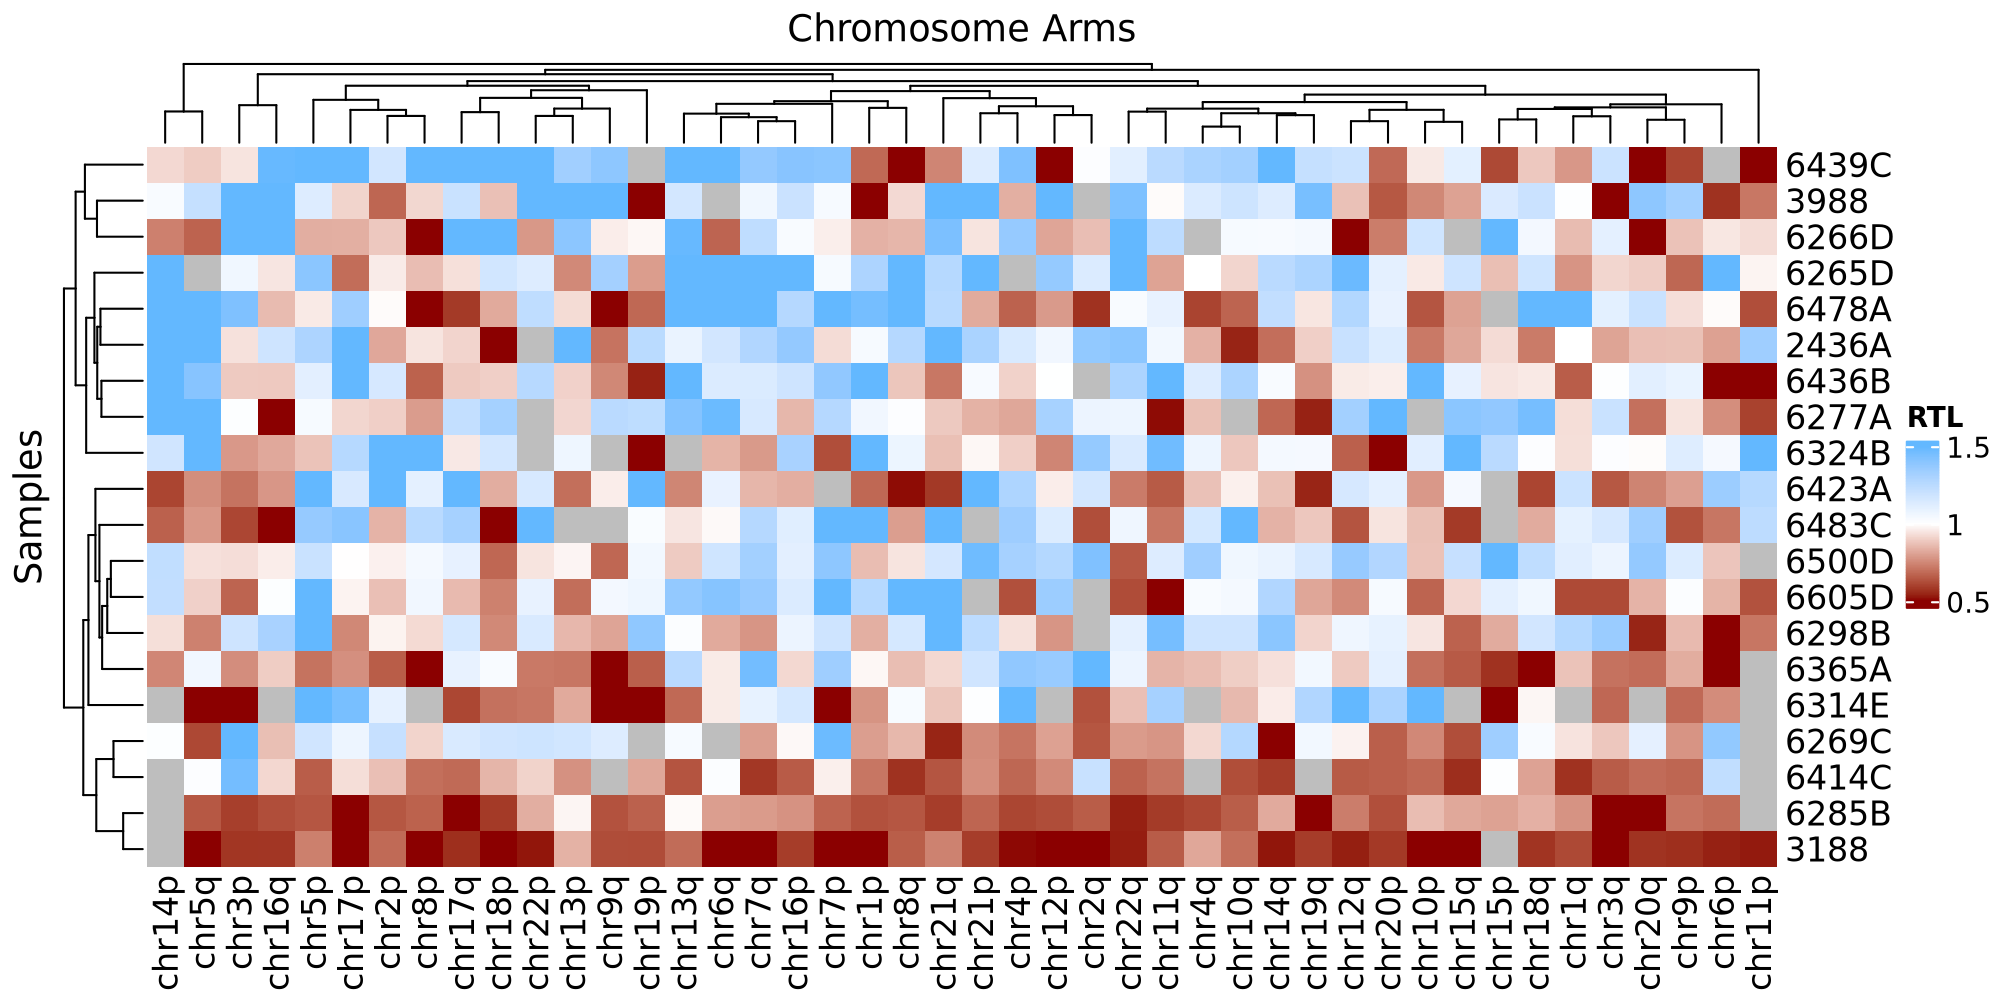

In [235]:
# Calculate global mean TL across all samples and arms
global_mean_TL <- mean(df$final_average_TL_p75, na.rm = TRUE)

# Add RTL column: TL divided by global mean
df <- df %>%
  mutate(RTL = final_average_TL_p75 / global_mean_TL)



# Make heatmap matrix
rtl_matrix <- df %>%
  select(Sample_prefix, chr_arm = chr, RTL) %>%
  pivot_wider(names_from = chr_arm, values_from = RTL) %>%
  column_to_rownames("Sample_prefix") %>%
  as.matrix()

# Color scale
rtl_colors <- colorRamp2(c(0.5, 1, 1.5), c("darkred", "white", "steelblue1"))

# Heatmap
ht_rtl <- Heatmap(
  rtl_matrix,
  name = "Global RTL",
  col = rtl_colors,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_title = "Samples",
  column_title = "Chromosome Arms",
  heatmap_legend_param = list(title = "RTL")
)

draw(ht_rtl)


In [236]:
head(rtl_matrix)

,chr1p,chr1q,chr2p,chr2q,chr3p,chr3q,chr4p,chr4q,chr5p,chr5q,⋯,chr18p,chr18q,chr19p,chr19q,chr20p,chr20q,chr21p,chr21q,chr22q,chr22p
2436A,1.0340362,1.0004002,0.8156330,1.3790450,0.9386141,0.8076712,1.1463819,0.8365606,1.2964073,2.0879190,⋯,0.4487557,0.7188344,1.2516473,0.9000532,1.1303099,0.8671565,1.3062770,1.8780601,1.4002566,NA
3188,0.3253025,0.6112915,0.6811548,0.3818467,0.5724730,0.4675642,0.5065873,0.8148903,0.7290342,0.4273990,⋯,0.4408666,0.5692547,0.6179593,0.5857756,0.5790583,0.5680663,0.5869309,0.7339855,0.5299906,0.5204444
3988,0.4649301,1.0067049,0.6723909,NA,1.9879599,0.4228862,0.8322199,1.1357366,1.1266591,1.2130104,⋯,0.8688598,1.1966380,0.4061578,1.4510374,0.6424849,1.3914234,1.6646379,1.7905008,1.4363155,1.6553294
6265D,1.2968529,0.7736622,0.9596425,1.1364298,1.0555250,0.9145111,NA,1.0008128,1.4014251,NA,⋯,1.1702309,1.1801995,0.7922132,1.2982393,1.1013743,0.8962159,2.0864666,1.2655605,1.5958144,1.1281115
6266D,0.8365771,0.8592542,0.8857933,0.8644531,2.5409247,1.1015724,1.3689443,NA,0.8289520,0.6678357,⋯,1.7196967,1.0448631,0.9826343,1.0439389,0.7231916,0.3794701,0.9437239,1.4404416,1.7191025,0.7821124
6269C,0.7959762,0.9420999,1.2097590,0.6383257,1.8163467,0.8837385,0.7049707,0.9182246,1.1749511,0.6096080,⋯,1.1760404,1.0270548,NA,1.0480980,0.6589728,1.0994928,0.7546821,0.5416757,0.7880540,1.1874285


In [237]:
write.table(rtl_matrix, file = "/home/mjehangir/telomere-sv-analysis/data/telomeres_RTL_matrix.txt", sep = "\t", quote = FALSE, row.names = TRUE)
